# Bước 1: Nhập và tiền xử lý ảnh

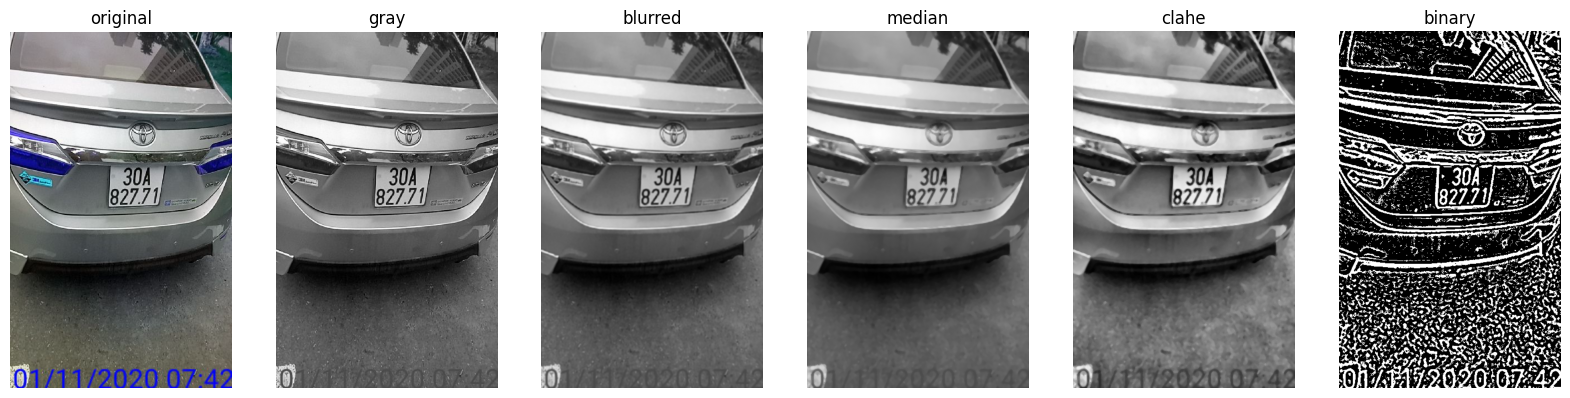

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Hàm để hiển thị hình ảnh
def display_image(images, titles):
    plt.figure(figsize=(20,10))
    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
def load_and_preprocess(image_path):
    # 1. Tải ảnh
    original_image = cv2.imread(image_path)
    if original_image is None:
        print("Lỗi: Không thể tải ảnh.")
    else:
        # 2. Tiền xử lý 
        # Chuyển đổi sang ảnh xám
        gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
        # Gaussian Blur để giảm nhiễu
        blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        # Median Filter để giảm nhiễu nhiều hơn
        median_image = cv2.medianBlur(blurred_image, 5)
        # CLAHE để tăng cường độ tương phản
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        clahe_image = clahe.apply(median_image)
        # Binarization để phát hiện contours (Dùng method Adaptive Thresholding)
        binary_image = cv2.adaptiveThreshold(
            clahe_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY_INV, 11, 2
        )
        # 3. Trả về một dictionary để dễ dàng truy cập các bước
        return {
            "original": original_image,
            "gray": gray_image,
            "blurred": blurred_image,
            "median": median_image,
            "clahe": clahe_image,
            "binary": binary_image
        }
# Test /Users/khoado/code/license-plate-recognition/data/test_images/CarTGMT/AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg
image_path = r'/Users/khoado/code/license-plate-recognition/data/test_images/CarTGMT/AQUA7_82771_checkin_2020-11-1-7-42qzNT0orBVD.jpg'
process_images = load_and_preprocess(image_path)
if process_images:
    display_image(list(process_images.values()), list(process_images.keys()))

# Bước 2 - 3: Phát hiện biển số xe bằng Canny Edge và Morphology


## Tạo hàm `detect_license_plate()`:
1. Tìm cạnh (Canny)
2. Đóng các khoảng trống (Phép đóng)
3. Loại bỏ nhiễu nhỏ (Phép mở)
4. Tìm đường viền (contours)
5. Lọc ra các đường viền phù hợp là biển số xe
6. In và Test

✓ Phát hiện 2 vùng biển số
  Plate 1: vị trí=(173, 244), kích thước=(109x77), tỷ lệ=1.42
  Plate 2: vị trí=(237, 0), kích thước=(163x134), tỷ lệ=1.22


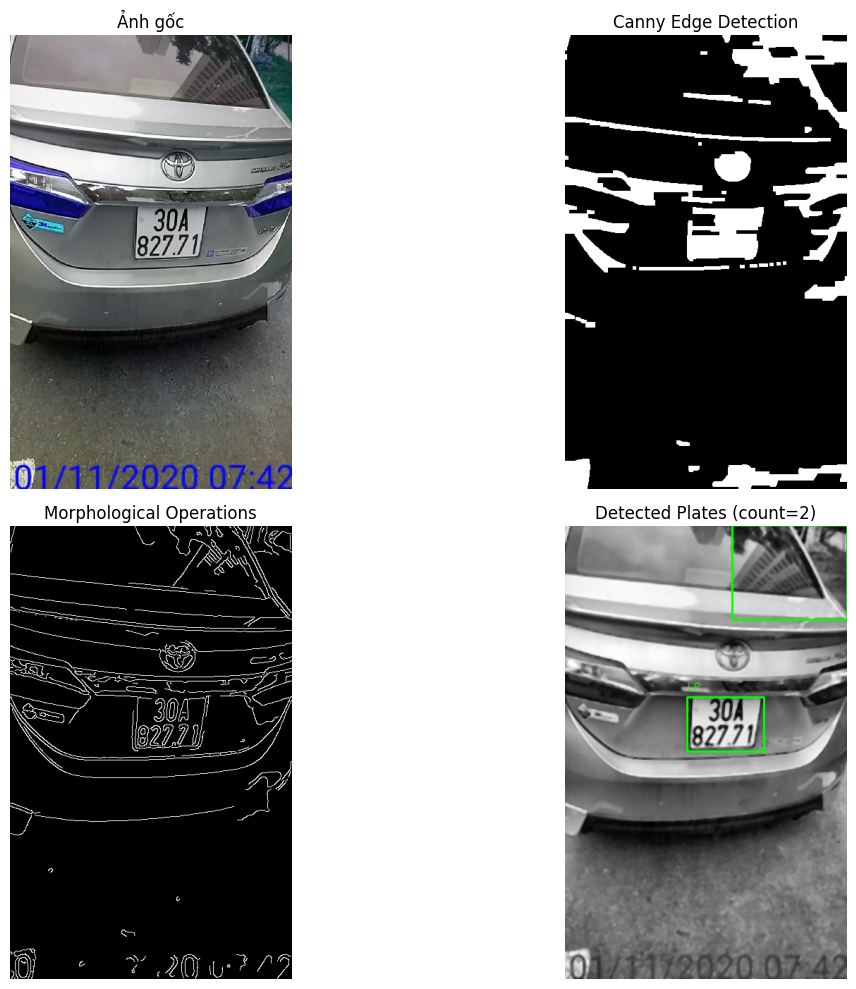

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detect_license_plate(image_preprocessed, canny_threshold1 = 100, canny_threshold2 = 200, 
                         min_area = 5000, aspect_ratio_range = (1.0, 2.5)):
    # 1. Phát hiện cạnh sử dụng Canny
    edges = cv2.Canny(image_preprocessed, canny_threshold1, canny_threshold2)
    
    # 2. Sử dụng Morphology để đóng các khoảng trống (phép đóng để nối các cạnh thành vùng liên tục)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    # 3. Phép mở để loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc contours dựa trên diện tích và tỷ lệ khung hình
    plates = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # kiểm tra điều kiện diện tích và tỷ lệ khung hình
        if (area >= min_area and 
            aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            plates.append((x, y, w, h))
    return plates, morph, edges

# Test
detected_plates, edges_img, morph_img = detect_license_plate(process_images['clahe'])

print(f"✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Ảnh gốc
axes[0, 0].imshow(process_images['original'], cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Ảnh Canny edges
axes[0, 1].imshow(edges_img, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

# Ảnh sau morphology
axes[1, 0].imshow(morph_img, cmap='gray')
axes[1, 0].set_title('Morphological Operations')
axes[1, 0].axis('off')

# Ảnh gốc với bounding boxes
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for (x, y, w, h) in detected_plates:
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Tinh chỉnh và nâng cấp hàm `detect_license_plate` với **Adaptive Threshold** & **Geometric Filters**
---
1. Tính tự động ngưỡng Canny bằng **Median-based adaptive**
2. Giữ nguyên các bước xử lý
3. Sau khi tìm contours sẽ áp dụng Geometric Filtering:
    - Diện tích 
    - Tỷ lệ khung hình 
    - Độ "đặc" 
    - Khoảng cách từ cạnh ảnh
4. Tiếp tục cải tiến Adaptive Area & Kernel Size
5. In và Test

In [18]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def auto_canny (image, sigma = 0.33):
    """
    Tính Canny thresholds tự động dựa trên median pixel value
    Phương pháp: Median-based Adaptive Thresholding (sử dụng Heuristic)
    Ý tưởng: Giả định các cạnh quan trọng trong ảnh sẽ có gradients cỡ median
    """
    # Tính median pixel value
    v = np.median(image)
    
    # Áp dụng sigma để tính lower và upper thresholds
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    return lower, upper
def detect_license_plate_v2(image_preprocessed,
                            sigma = 0.33,
                            min_area = 5000,
                            max_area = 50000,
                            aspect_ratio_range=(0.8, 3.5),
                            min_solidity = 0.5,
                            debug=False):
    """
    Args:
        image_preprocessed: Ảnh đã qua tiền xử lý (CLAHE)
        sigma: Hệ số Heuristic để tính Canny
        min_area, max_area:  Khoảng diện tích contour hợp lệ
        aspect_ratio_range: Khoảng W/H (nới lỏng để có nhiều trường hợp).
        min_solidity: Mức độ "đặc" của contour (0-1, cao = hình dạng rõ ràng)
        debug: In thông tin chi tiết
    Returns:
        plates: Danh sách bounding boxes của biển số được phát hiện
        debug_info: Dictionary chứa intermediate images & stats
    """
    # 1. Tính ngưỡng Canny tự động
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma = sigma)
    if debug:
        print(f"✓ Auto Canny thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # 2. Phát hiện cạnh 
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # 3. Xử lý hình thái (Morphology)
    # Phép đóng: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Phép mở: loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)   
    
    # 4. Tìm contours
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 5. Lọc Geometric 
    plates = []
    rejected_stats = {"area":0, "aspect_ratio":0, "solidity":0, "margin":0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Lọc 1: Diện tích
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Lọc 2: Tỷ lệ khung hình (W/H)
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Lọc 3: Độ "đặc" (solidity)
        # Solidity = Area / Convex Hull Area
        # Giá trị cao = hình dạng đặc (ít có lỗ), thấp = rỗng hoặc nhiễu
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Lọc 4: Khoảng cách từ cạnh ảnh (Tránh detect phần xe)
        margin = 10
        if x <= margin or y <= margin or (x + w) >= (image_preprocessed.shape[1] - margin) or (y + h) >= (image_preprocessed.shape[0] - margin):
            rejected_stats["margin"] += 1
            continue
        
        # Nếu vượt qua tất cả các bộ lọc, thêm vào danh sách plates
        plates.append((x, y, w, h))
        
        if debug:
            print(f"✓ Detected plate: pos=({x}, {y}), size=({w}x{h}), area={area}, aspect_ratio={aspect_ratio:.2f}, solidity={solidity:.2f}")
    # DEBUG INFO
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • Bị từ chối (margin): {rejected_stats['margin']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    return plates, debug_info
detect_license_plate_v2(process_images['clahe'], debug=True)

✓ Auto Canny thresholds: lower=76, upper=151
✓ Detected plate: pos=(173, 244), size=(116x77), area=7110.5, aspect_ratio=1.51, solidity=0.86

📈 Tổng kết:
  • Tìm được 35 contours
  • Bị từ chối (diện tích): 31
  • Bị từ chối (tỷ lệ): 2
  • Bị từ chối (solidity): 0
  • Bị từ chối (margin): 1
  • ✅ Phát hiện 1 biển số hợp lệ


([(173, 244, 116, 77)],
 {'edges': array([[  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         [  0,   0,   0, ...,   0,   0,   0],
         ...,
         [  0,   0, 255, ..., 255, 255, 255],
         [  0,   0, 255, ...,   0,   0,   0],
         [  0,   0, 255, ...,   0,   0,   0]], shape=(644, 400), dtype=uint8),
  'morph': array([[255, 255, 255, ...,   0,   0,   0],
         [255, 255, 255, ...,   0,   0,   0],
         [255, 255, 255, ...,   0,   0,   0],
         ...,
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255],
         [255, 255, 255, ..., 255, 255, 255]], shape=(644, 400), dtype=uint8),
  'contours': 35,
  'canny_lower': 76,
  'canny_upper': 151,
  'rejected': {'area': 31, 'aspect_ratio': 2, 'solidity': 0, 'margin': 1},
  'plates_count': 1})

📐 Image dimensions: 400x644, area=257600
   Adaptive area range: 5152-38640 (2.0%-15.0%)
📊 Auto Canny Thresholds: lower=76, upper=151
🔧 Adaptive kernel: close_kernel=(41, 13)

📈 Tổng kết:
  • Tìm được 15 contours
  • Bị từ chối (diện tích): 14
  • Bị từ chối (tỷ lệ): 1
  • Bị từ chối (solidity): 0
  • Bị từ chối (margin): 0
  • ✅ Phát hiện 0 biển số hợp lệ

✓ Phát hiện 0 vùng biển số


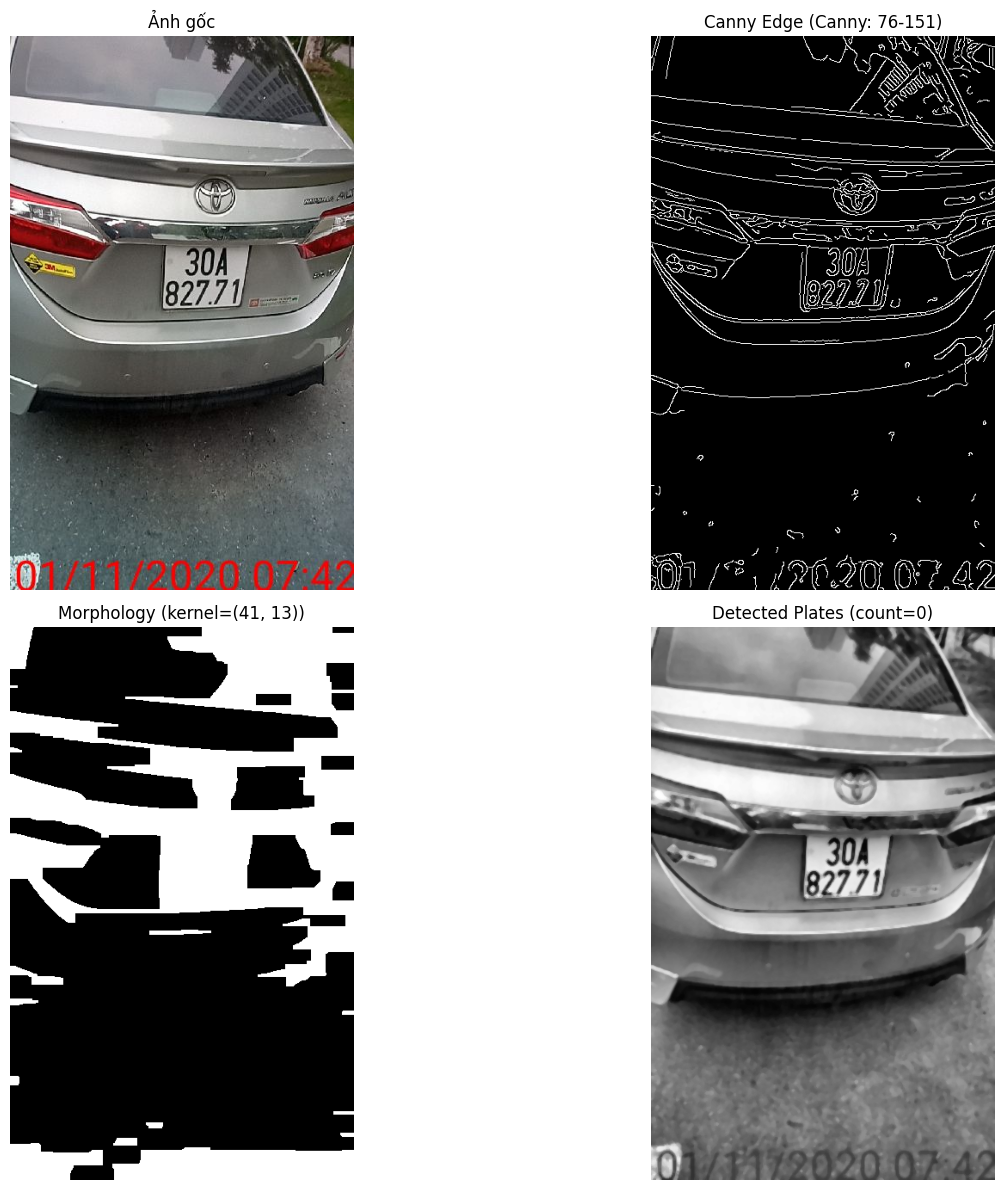

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """
    Tính tự động Canny thresholds dựa trên median pixel value.
    """
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3(image_preprocessed,
                             sigma=0.33,
                             area_ratio_range=(0.02, 0.15),  # 2%-15% của diện tích ảnh
                             aspect_ratio_range=(0.8, 3.5),
                             min_solidity=0.5,
                             kernel_width_ratio=0.1,  # 10% chiều rộng ảnh
                             kernel_height_ratio=0.02, # 2% chiều cao ảnh
                             debug=False):
    """
    Phát hiện biển số với Adaptive Parameters (tỷ lệ % diện tích ảnh).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: Tuple(min%, max%) - % diện tích ảnh (tỷ lệ 0-1)
                         VD: (0.02, 0.15) = 2%-15% diện tích ảnh
        aspect_ratio_range: Khoảng W/H của biển số
        min_solidity: Mức độ "đặc" của contour (0-1)
        kernel_width_ratio: % chiều rộng ảnh để tính kernel width (VD: 0.1 = 10%)
        kernel_height_ratio: % chiều cao ảnh để tính kernel height (VD: 0.02 = 2%)
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)] - bounding boxes
        debug_info: Dictionary chứa intermediate images & statistics
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    # ========== 1. ADAPTIVE AREA THRESHOLDS (dựa trên % diện tích ảnh) ==========
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image dimensions: {img_width}x{img_height}, area={img_area}")
        print(f"   Adaptive area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    # ========== 2. AUTO CANNY THRESHOLDS ==========
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Auto Canny Thresholds: lower={lower_canny}, upper={upper_canny}")
    
    # ========== 3. CANNY EDGE DETECTION ==========
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    # ========== 4. ADAPTIVE MORPHOLOGICAL OPERATIONS ==========
    # Tính kích thước kernel dựa trên kích thước ảnh
    kernel_width = max(5, int(img_width * kernel_width_ratio))
    kernel_height = max(3, int(img_height * kernel_height_ratio))
    
    # Đảm bảo kernel có kích thước lẻ (required by OpenCV)
    if kernel_width % 2 == 0:
        kernel_width += 1
    if kernel_height % 2 == 0:
        kernel_height += 1
    
    if debug:
        print(f"🔧 Adaptive kernel: close_kernel=({kernel_width}, {kernel_height})")
    
    # Close kernel: nối các cạnh thành vùng liên tục
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    
    # Open kernel: loại bỏ nhiễu nhỏ (nhỏ hơn close kernel)
    kernel_open_w = max(3, kernel_width // 5)
    kernel_open_h = max(3, kernel_height // 5)
    if kernel_open_w % 2 == 0:
        kernel_open_w += 1
    if kernel_open_h % 2 == 0:
        kernel_open_h += 1
    
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_open_w, kernel_open_h))
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    # ========== 5. FIND CONTOURS ==========
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # ========== 6. GEOMETRIC FILTERING ==========
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # **Filter 1: Diện tích (adaptive dựa % ảnh)**
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # **Filter 2: Tỷ lệ khung hình (W/H)**
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # **Filter 3: Solidity (độ "đặc" của contour)**
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # **Filter 4: Khoảng cách từ cạnh ảnh**
        margin = max(5, int(img_width * 0.05))  # 5% chiều rộng hoặc 5px (cái nào lớn hơn)
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Passed all filters
        plates.append((x, y, w, h))
        
        if debug:
            print(f"  ✓ Plate found: Area={area:.0f}, AR={aspect_ratio:.2f}, Solidity={solidity:.2f}")
    
    # ========== DEBUG INFO ==========
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": (kernel_width, kernel_height),
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Tổng kết:")
        print(f"  • Tìm được {len(contours)} contours")
        print(f"  • Bị từ chối (diện tích): {rejected_stats['area']}")
        print(f"  • Bị từ chối (tỷ lệ): {rejected_stats['aspect_ratio']}")
        print(f"  • Bị từ chối (solidity): {rejected_stats['solidity']}")
        print(f"  • Bị từ chối (margin): {rejected_stats['margin']}")
        print(f"  • ✅ Phát hiện {len(plates)} biển số hợp lệ")
    
    return plates, debug_info

# ========== TEST ==========
detected_plates, debug_info = detect_license_plate_v3(
    process_images['clahe'],
    sigma=0.33,
    area_ratio_range=(0.02, 0.15),  # 2%-15% diện tích ảnh
    kernel_width_ratio=0.1,          # 10% chiều rộng
    kernel_height_ratio=0.02,        # 2% chiều cao
    min_solidity=0.5,
    debug=True
)

print(f"\n✓ Phát hiện {len(detected_plates)} vùng biển số")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: vị trí=({x}, {y}), kích thước=({w}x{h}), tỷ lệ={w/h:.2f}")

# ========== VISUALIZE ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original image
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny edges
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny Edge (Canny: {debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology result
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result with detected plates
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Phiên bản Final: v3_hybrid (Adaptive Area + Fixed Kernel)
---
Kết hợp ưu điểm của v2 và v3:
- Adaptive Area (% diện tích ảnh) để linh hoạt với ảnh khác kích thước
- Fixed Kernel (25x5) để bảo toàn cấu trúc biển số như v2
- Auto Canny để thích ứng ánh sáng
- Geometric Filters để lọc chính xác

📐 Image: 400x644, area=257600
   Area range: 5152-64400 (2.0%-25.0%)
📊 Canny: 76-151
🔧 Kernel: fixed (25,5)
  ✓ Area=7110, AR=1.51, Sol=0.86

📈 Summary: 35 contours → 1 plates
   Rejected - area:31 AR:2 solidity:0 margin:1

Found 1 plates
  Plate 1: pos=(173, 244), size=(116x77), ratio=1.51


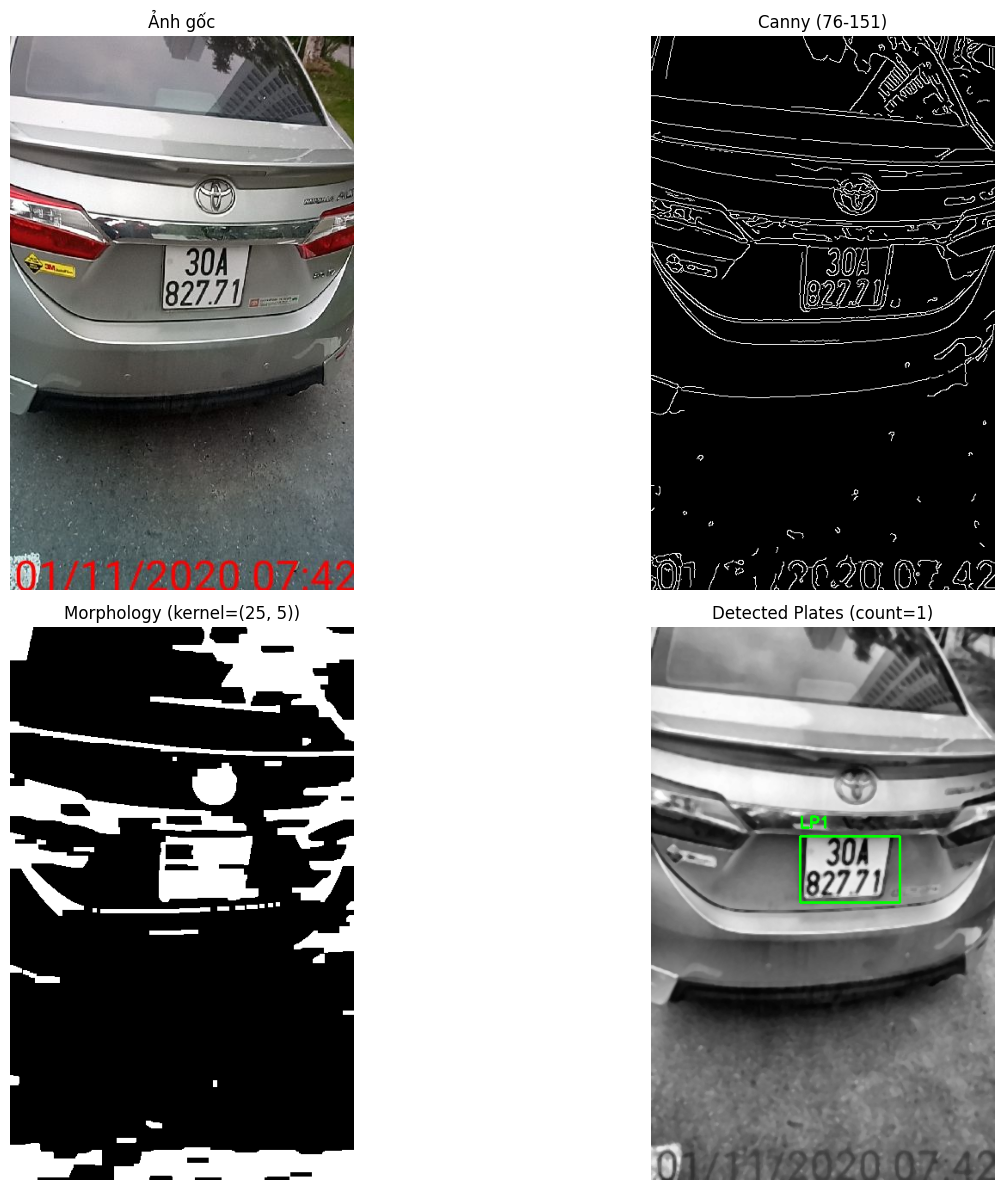

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def auto_canny(image, sigma=0.33):
    """Tính tự động Canny thresholds dựa trên median pixel value."""
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return lower, upper

def detect_license_plate_v3_hybrid(image_preprocessed,
                                    sigma=0.33,
                                    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
                                    aspect_ratio_range=(0.8, 3.5),
                                    min_solidity=0.5,
                                    use_fixed_kernel=True,  # Dùng fixed kernel như v2
                                    debug=False):
    """
    Phát hiện biển số - Hybrid: Adaptive Area + Fixed Kernel (v2 proven).
    
    Args:
        image_preprocessed: Ảnh grayscale đã tiền xử lý (CLAHE)
        sigma: Hệ số điều chỉnh Canny
        area_ratio_range: % diện tích ảnh (adaptive)
        aspect_ratio_range: Khoảng W/H
        min_solidity: Độ "đặc" tối thiểu
        use_fixed_kernel: True = dùng kernel v2 (25,5), False = adaptive
        debug: In thông tin chi tiết
    
    Returns:
        plates: List[(x, y, w, h)]
        debug_info: Dictionary với intermediate images & stats
    """
    
    img_height, img_width = image_preprocessed.shape
    img_area = img_height * img_width
    
    #  1. ADAPTIVE AREA THRESHOLDS 
    min_area = int(img_area * area_ratio_range[0])
    max_area = int(img_area * area_ratio_range[1])
    
    if debug:
        print(f"📐 Image: {img_width}x{img_height}, area={img_area}")
        print(f"   Area range: {min_area}-{max_area} ({area_ratio_range[0]*100:.1f}%-{area_ratio_range[1]*100:.1f}%)")
    
    #  2. AUTO CANNY 
    lower_canny, upper_canny = auto_canny(image_preprocessed, sigma=sigma)
    if debug:
        print(f"📊 Canny: {lower_canny}-{upper_canny}")
    
    edges = cv2.Canny(image_preprocessed, lower_canny, upper_canny)
    
    #  3. MORPHOLOGY - FIXED KERNEL (v2 proven) 
    if use_fixed_kernel:
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 5))  # ✓ v2 kernel
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = "fixed (25,5)"
        kernel_size = (25, 5)
    else:
        # Fallback: adaptive kernel nhỏ hơn
        kernel_width = max(5, int(img_width * 0.06))  # 6% chiều rộng
        kernel_height = max(3, int(img_height * 0.01))  # 1% chiều cao
        if kernel_width % 2 == 0:
            kernel_width += 1
        if kernel_height % 2 == 0:
            kernel_height += 1
        kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_width, kernel_height))
        kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        kernel_info = f"adaptive ({kernel_width},{kernel_height})"
        kernel_size = (kernel_width, kernel_height)
    
    morph = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel_open)
    
    if debug:
        print(f"🔧 Kernel: {kernel_info}")
    
    #  4. FIND CONTOURS 
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    #  5. GEOMETRIC FILTERING 
    plates = []
    rejected_stats = {"area": 0, "aspect_ratio": 0, "solidity": 0, "margin": 0}
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = cv2.contourArea(contour)
        aspect_ratio = w / h if h > 0 else 0
        
        # Filter 1: Diện tích (adaptive)
        if not (min_area <= area <= max_area):
            rejected_stats["area"] += 1
            continue
        
        # Filter 2: Tỷ lệ W/H
        if not (aspect_ratio_range[0] <= aspect_ratio <= aspect_ratio_range[1]):
            rejected_stats["aspect_ratio"] += 1
            continue
        
        # Filter 3: Solidity
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        if solidity < min_solidity:
            rejected_stats["solidity"] += 1
            continue
        
        # Filter 4: Margin (adaptive)
        margin = max(3, int(img_width * 0.03))
        if x < margin or y < margin or (x + w) > (img_width - margin) or (y + h) > (img_height - margin):
            rejected_stats["margin"] += 1
            continue
        
        # ✅ Pass all filters
        plates.append((x, y, w, h))
        if debug:
            print(f"  ✓ Area={area:.0f}, AR={aspect_ratio:.2f}, Sol={solidity:.2f}")
    
    #  DEBUG INFO 
    debug_info = {
        "edges": edges,
        "morph": morph,
        "contours": len(contours),
        "canny_lower": lower_canny,
        "canny_upper": upper_canny,
        "min_area": min_area,
        "max_area": max_area,
        "kernel_close": kernel_size,
        "rejected": rejected_stats,
        "plates_count": len(plates)
    }
    
    if debug:
        print(f"\n📈 Summary: {len(contours)} contours → {len(plates)} plates")
        print(f"   Rejected - area:{rejected_stats['area']} AR:{rejected_stats['aspect_ratio']} "
              f"solidity:{rejected_stats['solidity']} margin:{rejected_stats['margin']}")
    
    return plates, debug_info

#  TEST 
detected_plates, debug_info = detect_license_plate_v3_hybrid(
    process_images['clahe'],
    area_ratio_range=(0.02, 0.25),  # 2%-25% diện tích ảnh
    use_fixed_kernel=True,          # Dùng kernel v2
    debug=True
)

print(f"\nFound {len(detected_plates)} plates")
for idx, (x, y, w, h) in enumerate(detected_plates):
    print(f"  Plate {idx+1}: pos=({x}, {y}), size=({w}x{h}), ratio={w/h:.2f}")

#  VISUALIZE 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original
axes[0, 0].imshow(cv2.cvtColor(process_images['original'], cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# Canny
axes[0, 1].imshow(debug_info['edges'], cmap='gray')
axes[0, 1].set_title(f"Canny ({debug_info['canny_lower']}-{debug_info['canny_upper']})")
axes[0, 1].axis('off')

# Morphology
axes[1, 0].imshow(debug_info['morph'], cmap='gray')
axes[1, 0].set_title(f"Morphology (kernel={debug_info['kernel_close']})")
axes[1, 0].axis('off')

# Result
result_image = cv2.cvtColor(process_images['clahe'], cv2.COLOR_GRAY2BGR)
for idx, (x, y, w, h) in enumerate(detected_plates):
    cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result_image, f"LP{idx+1}", (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

axes[1, 1].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title(f'Detected Plates (count={len(detected_plates)})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## So sánh và biểu đồ của những phiên bản
---

Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-10-19-10-3VNDtBDGikR.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_80744_checkin_2020-10-26-14-54dqRyEOofRo.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_82771_checkin_2020-11-1-7-42qzNT0orBVD.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_78286_checkoutex_2020-10-24-7-35_t4_Sdhb7B.jpg
Lỗi: Không thể tải ảnh.
Lỗi tải ảnh: F:\code\XLA\data\test_images\CarTGMT\AQUA7_97662_checkin_2020-11-2-17-37AU9BTVtt4r.jpg


[ WARN:0@86.602] global loadsave.cpp:275 findDecoder imread_('F:\code\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg'): can't open/read file: check file path/integrity
[ WARN:0@86.603] global loadsave.cpp:275 findDecoder imread_('F:\code\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg'): can't open/read file: check file path/integrity
[ WARN:0@86.603] global loadsave.cpp:275 findDecoder imread_('F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg'): can't open/read file: check file path/integrity
[ WARN:0@86.603] global loadsave.cpp:275 findDecoder imread_('F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-10-19-10-3VNDtBDGikR.jpg'): can't open/read file: check file path/integrity
[ WARN:0@86.603] global loadsave.cpp:275 findDecoder imread_('F:\code\XLA\data\test_images\CarTGMT\AQUA7_80744_checkin_2020-10-26-14-54dqRyEOofRo.jpg'): can't open/read file: check file path/integrit

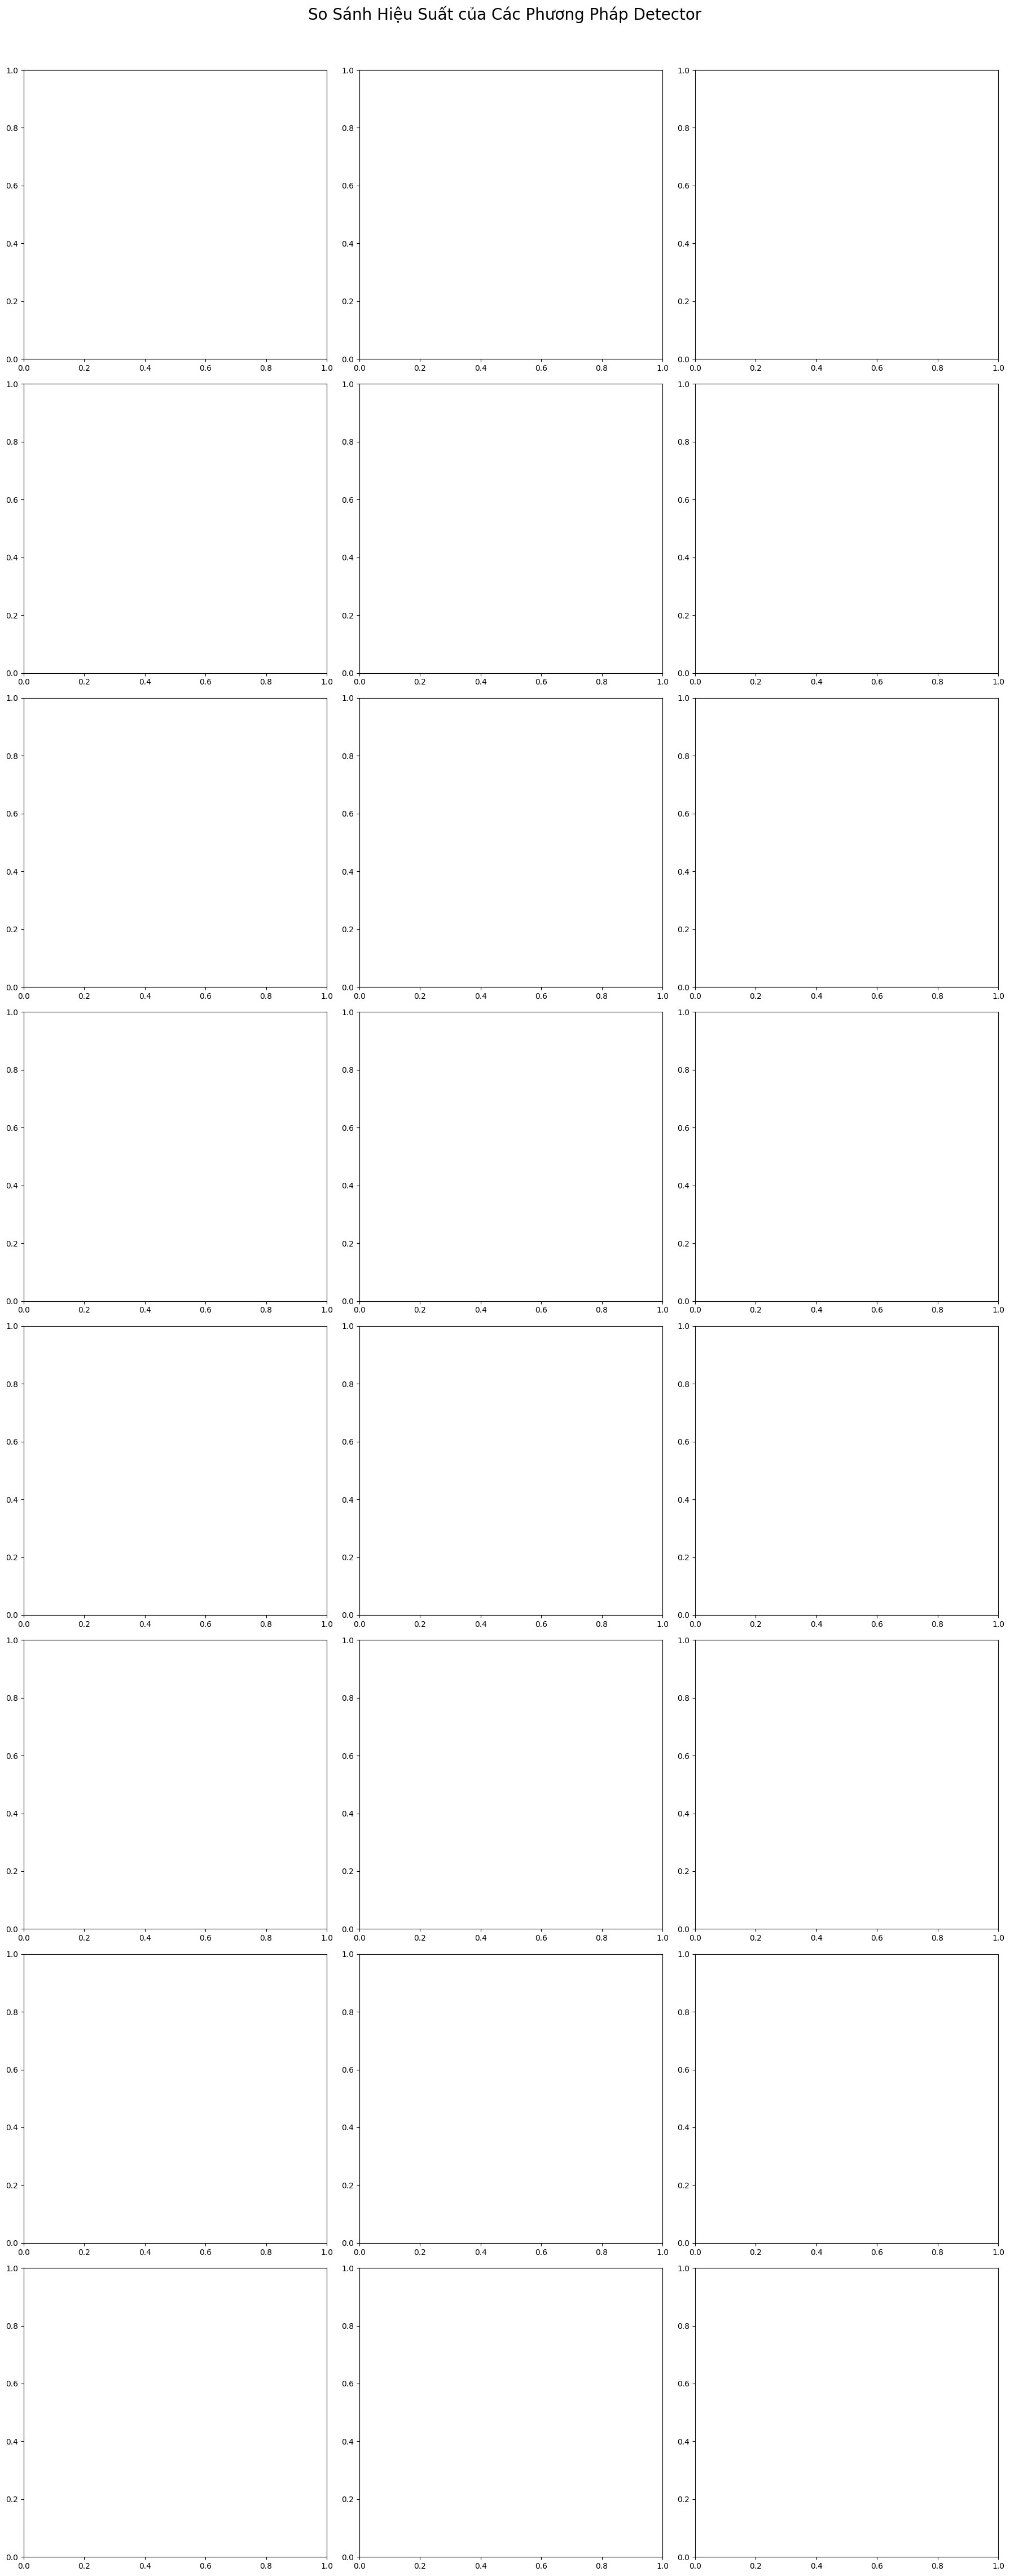

In [21]:
# SO SÁNH CÁC PHIÊN BẢN

# Các hàm detector để so sánh:
detectors_to_compare = {
    "v2": detect_license_plate_v2,
    "v3_adaptive": detect_license_plate_v3,
    "v3_hybrid": detect_license_plate_v3_hybrid
}

# Danh sách đường dẫn ảnh để kiểm tra (8)
comparison_image_paths = [
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-10-19-10-3VNDtBDGikR.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_80744_checkin_2020-10-26-14-54dqRyEOofRo.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_82771_checkin_2020-11-1-7-42qzNT0orBVD.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_78286_checkoutex_2020-10-24-7-35_t4_Sdhb7B.jpg',
    r'F:\code\XLA\data\test_images\CarTGMT\AQUA7_97662_checkin_2020-11-2-17-37AU9BTVtt4r.jpg'
]

# Thiết lập biểu đồ và chạy so sánh
num_images = len(comparison_image_paths)
num_detectors = len(detectors_to_compare)
fig, axes = plt.subplots(num_images, num_detectors, figsize=(18, 6 * num_images))
fig.suptitle('So Sánh Hiệu Suất của Các Phương Pháp Detector', fontsize=20)

if num_images == 1: axes = axes.reshape(1, -1)  

for i, image_path in enumerate(comparison_image_paths):
    # Tiền xử lý ảnh
    processed_imgs = load_and_preprocess(image_path)
    if not processed_imgs:
        print(f"Lỗi tải ảnh: {image_path}")
        continue
    
    clahe_img = processed_imgs['clahe']
    original_img = processed_imgs['original']
    
    for j, (detector_name, detector_func) in enumerate(detectors_to_compare.items()):
        # Chạy detector
        detected_plates, _ = detector_func(clahe_img, debug=False)
        
        # Vẽ hộp giới hạn trên ảnh gốc
        result_image = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        for (x, y, w, h) in detected_plates:
            cv2.rectangle(result_image, (x, y), (x+w, y+h), (0, 255, 0), 3)
        
        # Hiển thị kết quả
        ax = axes[i, j]
        ax.imshow(result_image)
        ax.set_title(f"{detector_name} - Biển Số: {len(detected_plates)}")
        ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== LẬP THỐNG KÊ DỮ LIỆU MỚI ==========
results_data = []

for i, image_path in enumerate(comparison_image_paths):
    processed_imgs = load_and_preprocess(image_path)
    if not processed_imgs:
        continue
    
    clahe_img = processed_imgs['clahe']
    original_img = processed_imgs['original']
    image_name = f"Img_{i+1}"  # Sử dụng đánh số để tránh trùng lặp
    
    for detector_name, detector_func in detectors_to_compare.items():
        plates, debug_info = detector_func(clahe_img, debug=False)
        
        # Đảm bảo Total_Contours được lưu trữ dưới dạng INT, không phải tuple
        total_contours = debug_info['contours']
        if isinstance(total_contours, tuple):
            total_contours = len(total_contours)
        
        results_data.append({
            'Image': image_name,
            'Detector': detector_name,
            'Plates_Found': len(plates),
            'Total_Contours': int(total_contours),
            'Rejected_Area': debug_info['rejected'].get('area', 0),
            'Rejected_AspectRatio': debug_info['rejected'].get('aspect_ratio', 0),
            'Rejected_Solidity': debug_info['rejected'].get('solidity', 0),
            'Rejected_Margin': debug_info['rejected'].get('margin', 0),
        })

# Chuyển đổi sang DataFrame để phân tích 
df_results = pd.DataFrame(results_data)
print(f"✓ Đã thu thập dữ liệu từ {len(df_results)} tổ hợp detector-image")
print(f"Loại dữ liệu:\n{df_results.dtypes}\n")

# ========== BIỂU ĐỒ 1: TỶ LỆ THÀNH CÔNG THEO DETECTOR ==========
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân tích Hiệu suất Detector', fontsize=18, fontweight='bold')

# Biểu đồ 1.1: Tổng số biển số được tìm thấy theo detector
ax1 = axes[0, 0]
plates_by_detector = df_results.groupby('Detector')['Plates_Found'].sum()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars1 = ax1.bar(plates_by_detector.index, plates_by_detector.values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax1.set_ylabel('Tổng Biển Số Được Tìm Thấy', fontsize=12, fontweight='bold')
ax1.set_title('1. Tổng Số Phát Hiện', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(plates_by_detector.values) * 1.2)
# Thêm nhãn giá trị trên các thanh
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 1.2: Tỷ lệ thành công (ảnh có ít nhất 1 biển số được phát hiện)
ax2 = axes[0, 1]
success_rates = df_results.groupby('Detector')['Plates_Found'].apply(
    lambda x: (x > 0).sum() / len(x) * 100
)
bars2 = ax2.bar(success_rates.index, success_rates.values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax2.set_ylabel('Tỷ Lệ Thành Công (%)', fontsize=12, fontweight='bold')
ax2.set_title('2. Tỷ Lệ Thành Công Phát Hiện', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 110)
# Thêm nhãn giá trị trên các thanh
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 2: Phân tích lý do từ chối
ax3 = axes[1, 0]
rejection_reasons = df_results.groupby('Detector')[['Rejected_Area', 'Rejected_AspectRatio', 'Rejected_Solidity', 'Rejected_Margin']].sum()
rejection_reasons.plot(kind='bar', ax=ax3, color=['#FF6B6B', '#FFA500', '#FFD93D', '#6BCB77'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Số Contours Bị Từ Chối', fontsize=12, fontweight='bold')
ax3.set_title('3. Phân Tích Lý Do Từ Chối', fontsize=13, fontweight='bold')
ax3.legend(['Diện Tích', 'Tỷ Lệ Khung Hình', 'Độ Đặc', 'Lề'], loc='upper center', fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Biểu đồ 3: Trung bình contours so với biển số được phát hiện
ax4 = axes[1, 1]
contour_stats = df_results.groupby('Detector')[['Total_Contours', 'Plates_Found']].mean()
x = np.arange(len(contour_stats.index))
width = 0.35
bars_contours = ax4.bar(x - width/2, contour_stats['Total_Contours'], width, label='Trung Bình Contours', color='#95E1D3', alpha=0.8, edgecolor='black', linewidth=1.5)
bars_plates = ax4.bar(x + width/2, contour_stats['Plates_Found'], width, label='Trung Bình Biển Số', color='#F38181', alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Số Lượng', fontsize=12, fontweight='bold')
ax4.set_title('4. Contours so với Biển Số Được Phát Hiện (Trung Bình)', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(contour_stats.index)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
# Thêm nhãn giá trị
for bars in [bars_contours, bars_plates]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ========== BIỂU ĐỒ 2: HEATMAP - HIỆU SUẤT DETECTOR TRÊN MỖI ẢNH ==========
fig, ax = plt.subplots(figsize=(12, 8))

# Bảng pivot: Ảnh × Detector với số biển số được phát hiện
heatmap_data = df_results.pivot_table(index='Image', columns='Detector', values='Plates_Found', aggfunc='first')

# Tạo heatmap
sns.heatmap(heatmap_data, annot=True, fmt='g', cmap='RdYlGn', cbar_kws={'label': 'Biển Số Được Tìm Thấy'}, 
            linewidths=2, linecolor='black', ax=ax, vmin=0, vmax=heatmap_data.max().max())
ax.set_title('Heatmap Phát Hiện: Biển Số Được Tìm Thấy trên Mỗi Ảnh × Detector', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Phiên Bản Detector', fontsize=12, fontweight='bold')
ax.set_ylabel('Ảnh', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ========== BIỂU ĐỒ 3: BẢNG SO SÁNH CHI TIẾT ==========
fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('tight')
ax.axis('off')

# Tạo bảng tóm tắt
summary_data = []
for detector in detectors_to_compare.keys():
    detector_df = df_results[df_results['Detector'] == detector]
    summary_data.append([
        detector,
        f"{detector_df['Plates_Found'].sum():.0f}",
        f"{(detector_df['Plates_Found'] > 0).sum()}/{len(detector_df)}",
        f"{detector_df['Plates_Found'].mean():.2f}",
        f"{detector_df['Total_Contours'].mean():.1f}",
        f"{detector_df[['Rejected_Area', 'Rejected_AspectRatio', 'Rejected_Solidity', 'Rejected_Margin']].sum(axis=1).mean():.1f}",
    ])

table = ax.table(cellText=summary_data,
                colLabels=['Detector', 'Tổng\nBiển Số', 'Tỷ Lệ\nThành Công', 'TB Biển Số\ntrên Ảnh', 'TB\nContours', 'TB\nBị Từ Chối'],
                cellLoc='center',
                loc='center',
                colWidths=[0.15, 0.15, 0.15, 0.2, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Định dạng tiêu đề
for i in range(len(table.get_children())):
    cell = table.get_children()[i]
    if i < 6:  # Hàng tiêu đề
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(weight='bold', color='white')
    else:
        if (i - 6) // 6 % 2 == 0:
            cell.set_facecolor('#E8F4F8')
        else:
            cell.set_facecolor('#D4E8F0')

plt.title('Bảng Thống Kê Tóm Tắt', fontsize=14, fontweight='bold', pad=20)
plt.show()

# ========== IN RA CÁC THÔNG TIN CHI TIẾT ==========
print("\n" + "="*80)
print("PHÂN TÍCH CHI TIẾT")
print("="*80)

for detector in detectors_to_compare.keys():
    detector_df = df_results[df_results['Detector'] == detector]
    print(f"\n{detector.upper()}:")
    print(f"   • Tổng biển số được tìm thấy: {detector_df['Plates_Found'].sum()}")
    print(f"   • Tỷ lệ thành công: {(detector_df['Plates_Found'] > 0).sum()}/{len(detector_df)} ({(detector_df['Plates_Found'] > 0).sum() / len(detector_df) * 100:.1f}%)")
    print(f"   • Trung bình biển số trên mỗi ảnh: {detector_df['Plates_Found'].mean():.2f}")
    print(f"   • Trung bình contours được tìm thấy: {detector_df['Total_Contours'].mean():.1f}")
    print(f"   • Tổng số lần từ chối:")
    print(f"      - Diện tích: {detector_df['Rejected_Area'].sum()}")
    print(f"      - Tỷ lệ khung hình: {detector_df['Rejected_AspectRatio'].sum()}")
    print(f"      - Độ đặc: {detector_df['Rejected_Solidity'].sum()}")
    print(f"      - Lề: {detector_df['Rejected_Margin'].sum()}")

print("\n" + "="*80)

ModuleNotFoundError: No module named 'pandas'

# Bước 4: Chuẩn hóa và phân tách ký tự (Segmentation)

## Chuyển biển số sang ảnh nhị phân **(Otsu Threshold)**


✓ Cắt vùng biển số: vị trí=(173, 244), kích thước=(116x77)
📊 Otsu Threshold Value: 141.0
✅ Morphological operations applied
 Ảnh biển số: (77, 116, 3)
 Phương pháp nhị phân hóa: otsu


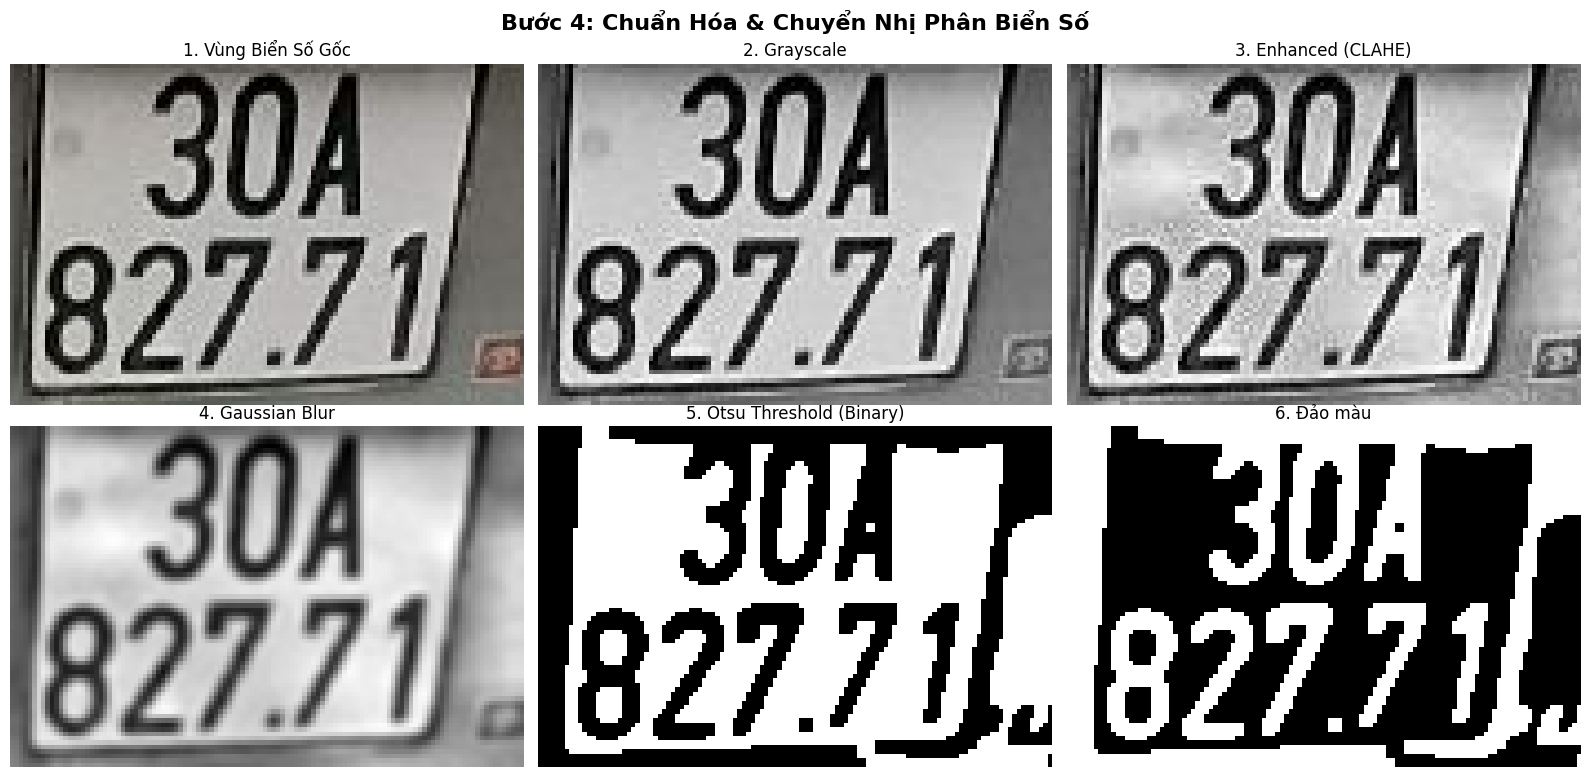


✅ Binarization thành công!
   Input shape: (77, 116, 3)
   Output shape: (77, 116)
   Pixel trắng (foreground): 5239 / 8932
   Pixel đen (background): 3693 / 8932


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def binarize_license_plate(plate_roi, method='otsu', debug=False):
    """
    Chuyển vùng biển số sang ảnh nhị phân để chuẩn bị phân tách ký tự.
    
    Args:
        plate_roi: Vùng biển số được cắt từ ảnh gốc (BGR hoặc grayscale)
        method: 'otsu' (mặc định) hoặc 'adaptive'
        debug: In thông tin chi tiết
    
    Returns:
        binary_plate: Ảnh nhị phân
        preprocessed_plate: Ảnh grayscale sau tiền xử lý (trước binarization)
        debug_info: Dictionary chứa intermediate images
    """
    
    # 1. Chuyển sang grayscale nếu biển số là ảnh màu
    if len(plate_roi.shape) == 3: gray_plate = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY)
    else: gray_plate = plate_roi
    
    # 2. Áp dụng CLAHE để tăng cường độ tương phản
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_plate = clahe.apply(gray_plate)
    
    # 3. Áp dụng Gaussian Blur để giảm nhiễu
    blurred_plate = cv2.GaussianBlur(enhanced_plate, (5, 5), 0)
    
    # 4. Binarization - Otsu Threshold 
    if method == 'otsu':
        threshold_value, binary_plate = cv2.threshold(
            blurred_plate, 0, 255, 
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        if debug:
            print(f"📊 Otsu Threshold Value: {threshold_value}")
    elif method == 'adaptive':
        binary_plate = cv2.adaptiveThreshold(
            blurred_plate, 255, 
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
            cv2.THRESH_BINARY, 
            11, 2
        )
        if debug:
            print("📊 Adaptive Thresholding applied")
    else:
        raise ValueError("Phương pháp không hợp lệ. Chọn 'otsu' hoặc 'adaptive'.")
    
    # 5. Morphological Operations để làm sạch ảnh nhị phân
    # Phép đóng: nối các vùng trắng liền kề  
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary_plate = cv2.morphologyEx(binary_plate, cv2.MORPH_CLOSE, kernel_close)

    # Phép mở: loại bỏ nhiễu nhỏ
    kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary_plate = cv2.morphologyEx(binary_plate, cv2.MORPH_OPEN, kernel_open)
    
    if debug:
        print("✅ Morphological operations applied")
    
    # Debug info
    debug_info = {
        "gray_plate": gray_plate,
        "enhanced_plate": enhanced_plate,
        "blurred_plate": blurred_plate,
        "binary_plate": binary_plate
    }
    
    if debug:
        print(f" Ảnh biển số: {plate_roi.shape}")
        print(f" Phương pháp nhị phân hóa: {method}")
        
    return binary_plate, blurred_plate, debug_info
    
# ========= TEST & VISUALIZE Binarization ==========
detect_plates, debug_info_detect = detect_license_plate_v3_hybrid(
    process_images['clahe'],
    use_fixed_kernel=True,
    debug=False
)
if len(detect_plates) > 0:
    # Lấy vùng biển số đầu tiên
    x, y, w, h = detect_plates[0]
    plate_roi = process_images['original'][y:y+h, x:x+w]
    
    print(f"\n✓ Cắt vùng biển số: vị trí=({x}, {y}), kích thước=({w}x{h})")
    
    # Binarize vùng biển số
    binary_plate, preprocessed_plate, debug_info_binarize_otsu = binarize_license_plate(
        plate_roi,
        method='otsu',
        debug=True
    )
    
    
    # Đảo màu để ký tự trắng trên nền đen
    inv_otsu = cv2.bitwise_not(binary_plate)
    
    # Hiển thị kết quả
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle('Bước 4: Chuẩn Hóa & Chuyển Nhị Phân Biển Số', fontsize=16, fontweight='bold')
    
    # Original plate
    axes[0, 0].imshow(cv2.cvtColor(plate_roi, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('1. Vùng Biển Số Gốc')
    axes[0, 0].axis('off')
    
    # Grayscale
    axes[0, 1].imshow(debug_info_binarize_otsu['gray_plate'], cmap='gray')
    axes[0, 1].set_title('2. Grayscale')
    axes[0, 1].axis('off')
    
    # Enhanced (CLAHE)
    axes[0, 2].imshow(debug_info_binarize_otsu['enhanced_plate'], cmap='gray')
    axes[0, 2].set_title('3. Enhanced (CLAHE)')
    axes[0, 2].axis('off')
    
    # Blurred
    axes[1, 0].imshow(debug_info_binarize_otsu['blurred_plate'], cmap='gray')
    axes[1, 0].set_title('4. Gaussian Blur')
    axes[1, 0].axis('off')
    
    # Binary (Otsu)
    axes[1, 1].imshow(debug_info_binarize_otsu['binary_plate'], cmap='gray')
    axes[1, 1].set_title('5. Otsu Threshold (Binary)')
    axes[1, 1].axis('off')
    
    # Side-by-side: Original vs Binary
    axes[1, 2].imshow(inv_otsu, cmap='gray')
    axes[1, 2].set_title('6. Đảo màu')
    axes[1, 2].axis('off')
    
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Binarization thành công!")
    print(f"   Input shape: {plate_roi.shape}")
    print(f"   Output shape: {binary_plate.shape}")
    print(f"   Pixel trắng (foreground): {np.sum(binary_plate == 255)} / {binary_plate.size}")
    print(f"   Pixel đen (background): {np.sum(binary_plate == 0)} / {binary_plate.size}")
else:
    print("⚠️ Không tìm thấy vùng biển số để cắt và binarize.")
    

## Tìm contours

### Bước 4.2 — Tìm Contour Ký Tự (Find character contours)
Mục tiêu: lấy ra các contour ký tự từ ảnh nhị phân biển số, lọc theo hình học (diện tích, tỉ lệ, chiều cao) và trực quan hóa kết quả.

🔍 Kết quả chiến lược:
  - S1-otsu: 6 boxes
  - S2-adapt: 8 boxes
  - S3-otsu-open: 3 boxes
  - S4-rowBands: 1 boxes
  - S5-blackhat: 9 boxes
  - S6-MSERTop+BottomCC: 16 boxes
  - S6R-MSER-refine: 8 boxes
➡️ Chọn: S2-adapt với 8 boxes


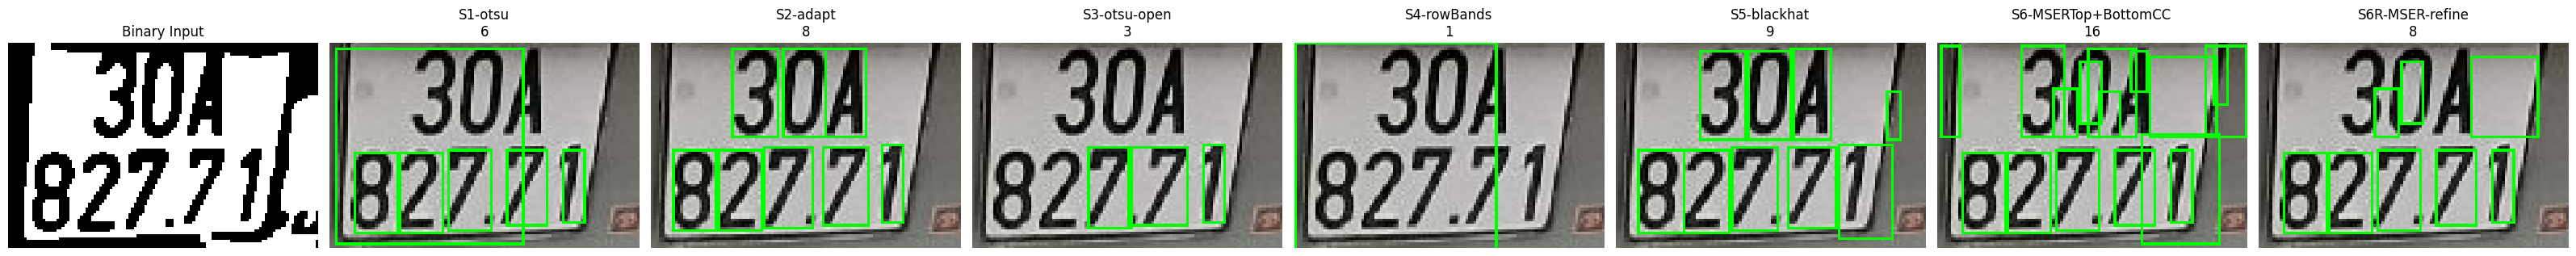

In [24]:
import cv2, numpy as np, matplotlib.pyplot as plt

def find_character_contours(binary_plate: np.ndarray, plate_roi: np.ndarray, debug: bool=True):
    """
    Multi-strategy phân đoạn ký tự hướng tới đúng 8 ký tự cho biển kiểu '30F78286'.
    Chiến lược: S1..S6 ban đầu + refine S5/S6 thành S5R/S6R bằng heuristic tách 3 ký tự hàng trên + 5 ký tự hàng dưới.
    Quy tắc chọn: ưu tiên chiến lược có đúng 8 box; nếu không có thì chọn nhiều nhất dưới 8; nếu tất cả >8 thì chọn cái vượt ít nhất.
    """
    target_chars = 8
    h_full, w_full = binary_plate.shape[:2]

    # ----- Helper: tách blob rộng -----
    def vertical_split(x,y,w,h,mask):
        roi = mask[y:y+h, x:x+w]
        proj = np.sum(roi>0, axis=0).astype(np.float32)
        k = max(3, (w//18)|1)
        smooth = cv2.GaussianBlur(proj.reshape(1,-1), (k,1), 0).ravel()
        thr = 0.42 * np.max(smooth)
        valleys = (smooth < thr).astype(np.uint8)
        in_v=False; cuts=[]; st=0
        for i,v in enumerate(valleys):
            if v and not in_v: in_v=True; st=i
            elif not v and in_v: in_v=False; cuts.append((st,i))
        if in_v: cuts.append((st,len(valleys)))
        mids=[(a+b)//2 for a,b in cuts if 4 < (a+b)//2 < w-4]
        segs=[]
        if 1 <= len(mids) <= 2:  # cho 2 hoặc 3 ký tự
            prev=0
            for mc in mids + [w]:
                seg_w = mc - prev
                if seg_w >= max(6,int(0.06*w_full)):
                    segs.append((x+prev, y, seg_w, h))
                prev = mc
        return segs if segs else [(x,y,w,h)]

    # ----- Helper: CC filter trên mask đã crop frame -----
    def cc_filter(base_mask, margin, params):
        inner = base_mask[margin:h_full-margin, margin:w_full-margin].copy()
        if params.get('open_ksize'):
            k = cv2.getStructuringElement(cv2.MORPH_RECT,(params['open_ksize'], params['open_ksize']))
            inner = cv2.morphologyEx(inner, cv2.MORPH_OPEN, k, 1)
        if params.get('use_dilate'):
            inner = cv2.dilate(inner, cv2.getStructuringElement(cv2.MORPH_RECT,(2,2)), 1)
        h,w = inner.shape[:2]
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((inner>0).astype('uint8'), connectivity=8)
        boxes=[]
        min_area = max(18, int(params['area_scale'] * 0.0006 * w * h))
        max_area = int(0.38 * w * h)
        min_ar, max_ar = 0.10, 1.02
        min_hf, max_hf = 0.18, 1.06
        min_den, max_den = 0.15, 0.96
        for i in range(1, num_labels):
            x = stats[i, cv2.CC_STAT_LEFT]; y = stats[i, cv2.CC_STAT_TOP]
            bw = stats[i, cv2.CC_STAT_WIDTH]; bh = stats[i, cv2.CC_STAT_HEIGHT]; area = stats[i, cv2.CC_STAT_AREA]
            if area < min_area or area > max_area: continue
            ar = bw/float(bh)
            if ar < min_ar or ar > max_ar: continue
            hf = bh/float(h)
            if hf < min_hf or hf > max_hf: continue
            roi = inner[y:y+bh, x:x+bw]
            dens = float(np.count_nonzero(roi))/(bw*bh+1e-6)
            if dens < min_den or dens > max_den: continue
            boxes.append((x+margin, y+margin, bw, bh))
        expanded=[]
        for (x,y,bw,bh) in boxes:
            if bw > 1.35*bh:
                expanded.extend(vertical_split(x,y,bw,bh,base_mask))
            else:
                expanded.append((x,y,bw,bh))
        def iou(b1,b2):
            x1,y1,w1,h1=b1; x2,y2,w2,h2=b2
            xa=max(x1,x2); ya=max(y1,y2)
            xb=min(x1+w1,x2+w2); yb=min(y1+h1,y2+h2)
            inter=max(0,xb-xa)*max(0,yb-ya)
            union=w1*h1+w2*h2-inter+1e-6
            return inter/union
        kept=[]
        for b in sorted(expanded, key=lambda b:b[2]*b[3], reverse=True):
            if all(iou(b,k)<0.28 for k in kept): kept.append(b)
        if kept:
            my = np.median([y+hh/2 for (_,y,_,hh) in kept])
            kept = sorted(kept, key=lambda b:(0 if (b[1]+b[3]/2)<my else 1, b[0]))
        return kept, inner

    # ----- Strategy S4 -----
    def strategy_row_bands(inv_mask):
        row_proj = np.sum(inv_mask>0, axis=1).astype(np.float32)
        k_rows = max(3,(h_full//20)|1)
        smooth = cv2.GaussianBlur(row_proj.reshape(-1,1),(1,k_rows),0).ravel()
        thr = 0.10*np.max(smooth)
        active = smooth>thr
        bands=[]; in_band=False; st=0
        for i,v in enumerate(active):
            if v and not in_band: in_band=True; st=i
            elif not v and in_band: in_band=False; bands.append((st,i))
        if in_band: bands.append((st,h_full))
        bands = [(a,b) for (a,b) in bands if (b-a) > h_full*0.15]
        bands = sorted(bands, key=lambda ab: ab[0])[:2]
        boxes=[]
        for (y0,y1) in bands:
            band = inv_mask[y0:y1,:]
            k3 = cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))
            band_clean = cv2.morphologyEx(band, cv2.MORPH_OPEN, k3,1)
            band_clean = cv2.dilate(band_clean, cv2.getStructuringElement(cv2.MORPH_RECT,(2,2)),1)
            num_labels, _, stats, _ = cv2.connectedComponentsWithStats((band_clean>0).astype('uint8'), connectivity=8)
            for i in range(1,num_labels):
                x = stats[i, cv2.CC_STAT_LEFT]; y = stats[i, cv2.CC_STAT_TOP]
                bw = stats[i, cv2.CC_STAT_WIDTH]; bh = stats[i, cv2.CC_STAT_HEIGHT]; area = stats[i, cv2.CC_STAT_AREA]
                if area < 15 or area > 0.40*(w_full*(y1-y0)): continue
                ar = bw/float(bh)
                if ar < 0.09 or ar > 1.05: continue
                hf = bh/float(y1-y0)
                if hf < 0.45 or hf > 1.10: continue
                roi = band_clean[y:y+bh, x:x+bw]
                dens = float(np.count_nonzero(roi))/(bw*bh+1e-6)
                if dens < 0.14 or dens > 0.97: continue
                boxes.append((x, y0+y, bw, bh))
        final=[]
        for (x,y,bw,bh) in boxes:
            if bw > 1.32*bh:
                final.extend(vertical_split(x,y,bw,bh,inv_mask))
            else:
                final.append((x,y,bw,bh))
        def iou(b1,b2):
            x1,y1,w1,h1=b1; x2,y2,w2,h2=b2
            xa=max(x1,x2); ya=max(y1,y2)
            xb=min(x1+w1,x2+w2); yb=min(y1+h1,y2+h2)
            inter=max(0,xb-xa)*max(0,yb-ya)
            union=w1*h1+w2*h2-inter+1e-6
            return inter/union
        kept=[]
        for b in sorted(final, key=lambda b:b[2]*b[3], reverse=True):
            if all(iou(b,k)<0.30 for k in kept): kept.append(b)
        if kept:
            my = np.median([y+hh/2 for (_,y,_,hh) in kept])
            kept = sorted(kept, key=lambda b:(0 if (b[1]+b[3]/2)<my else 1, b[0]))
        return kept

    # ----- Strategy S5 -----
    def strategy_blackhat(gray_img):
        blur = cv2.GaussianBlur(gray_img,(5,5),0)
        k = cv2.getStructuringElement(cv2.MORPH_RECT,(9,9))
        black = cv2.morphologyEx(blur, cv2.MORPH_BLACKHAT, k)
        black = cv2.normalize(black, None, 0, 255, cv2.NORM_MINMAX)
        _, th = cv2.threshold(black,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
        th = cv2.dilate(th, cv2.getStructuringElement(cv2.MORPH_RECT,(2,2)), 1)
        boxes, _ = cc_filter(th, 2, {"area_scale":0.8, "open_ksize":None, "use_dilate":False})
        return boxes, th

    # ----- Strategy S6 -----
    def strategy_mser_top(gray_img):
        top_h = int(0.48*h_full)
        top = gray_img[:top_h, :]
        mser = cv2.MSER_create(delta=3, min_area=30, max_area=int(0.25*top_h*w_full))
        regions, _ = mser.detectRegions(top)
        boxes=[]
        for pts in regions:
            x,y,w,h = cv2.boundingRect(pts)
            ar = w/float(h)
            if ar < 0.15 or ar > 0.9: continue
            hf = h/float(top_h)
            if hf < 0.25 or hf > 0.95: continue
            boxes.append((x, y, w, h))
        def iou(b1,b2):
            x1,y1,w1,h1=b1; x2,y2,w2,h2=b2
            xa=max(x1,x2); ya=max(y1,y2)
            xb=min(x1+w1,x2+w2); yb=min(y1+h1,y2+h2)
            inter=max(0,xb-xa)*max(0,yb-ya)
            union=w1*h1+w2*h2-inter+1e-6
            return inter/union
        kept=[]
        for b in sorted(boxes, key=lambda b:b[2]*b[3], reverse=True):
            if all(iou(b,k)<0.35 for k in kept): kept.append(b)
        if kept: kept = sorted(kept, key=lambda b:b[0])
        return kept

    # ----- Chuẩn bị mask / ảnh xám -----
    inv_otsu = cv2.bitwise_not(binary_plate)
    gray = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY) if len(plate_roi.shape)==3 else plate_roi.copy()
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enh = clahe.apply(gray)
    blur = cv2.GaussianBlur(enh,(5,5),0)
    adaptive = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 3)
    inv_adapt = cv2.bitwise_not(adaptive)
    _, otsu_raw = cv2.threshold(blur,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    inv_otsu_open = cv2.bitwise_not(cv2.morphologyEx(otsu_raw, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT,(3,3))))

    strategies = []
    for name, mask, params in [
        ("S1-otsu", inv_otsu,  {"margin":2, "area_scale":1.0, "open_ksize":None, "use_dilate":False}),
        ("S2-adapt", inv_adapt,{"margin":2, "area_scale":0.9, "open_ksize":None, "use_dilate":False}),
        ("S3-otsu-open", inv_otsu_open,{"margin":2, "area_scale":0.9, "open_ksize":None, "use_dilate":False}),
    ]:
        boxes, inner = cc_filter(mask, params['margin'], params)
        strategies.append((name, boxes, mask, inner))

    s4_boxes = strategy_row_bands(inv_otsu)
    strategies.append(("S4-rowBands", s4_boxes, inv_otsu, inv_otsu))

    s5_boxes, s5_mask = strategy_blackhat(enh)
    strategies.append(("S5-blackhat", s5_boxes, s5_mask, s5_mask))

    s6_top = strategy_mser_top(enh)
    bottom_band = inv_otsu[int(0.45*h_full):,:]
    bb_boxes, _ = cc_filter(bottom_band, 0, {"area_scale":1.0, "open_ksize":None, "use_dilate":False})
    s6_boxes = [(x, y+int(0.45*h_full), w, h) for (x,y,w,h) in bb_boxes if y+int(0.45*h_full) >= int(0.45*h_full)] + s6_top
    def iou_g(b1,b2):
        x1,y1,w1,h1=b1; x2,y2,w2,h2=b2
        xa=max(x1,x2); ya=max(y1,y2)
        xb=min(x1+w1,x2+w2); yb=min(y1+h1,y2+h2)
        inter=max(0,xb-xa)*max(0,yb-ya)
        union=w1*h1+w2*h2-inter+1e-6
        return inter/union
    s6_kept=[]
    for b in sorted(s6_boxes, key=lambda b:b[2]*b[3], reverse=True):
        if all(iou_g(b,k)<0.28 for k in s6_kept): s6_kept.append(b)
    if s6_kept:
        my = np.median([y+hh/2 for (_,y,_,hh) in s6_kept])
        s6_kept = sorted(s6_kept, key=lambda b:(0 if (b[1]+b[3]/2)<my else 1, b[0]))
    strategies.append(("S6-MSERTop+BottomCC", s6_kept, inv_otsu, inv_otsu))

    # ----- Refine heuristic để cố đạt đúng 8 từ S5 hoặc S6 -----
    def refine_to_8(boxes):
        if len(boxes) < target_chars: return None
        # loại các hộp quá sát mép nhỏ -> frame
        filtered=[b for b in boxes if b[0]>2 and b[0]+b[2]<w_full-2 and b[1]>2 and b[1]+b[3]<h_full-2]
        if len(filtered) >= target_chars: boxes=filtered
        # split row theo median y
        cy = [y+h/2 for (_,y,_,h) in boxes]
        mid = np.median(cy)
        top = [b for b in boxes if b[1]+b[3]/2 < mid]
        bot = [b for b in boxes if b[1]+b[3]/2 >= mid]
        # chọn 5 lớn nhất hàng dưới theo area rồi sort x
        bot_sel = sorted(bot, key=lambda b:b[2]*b[3], reverse=True)[:5]
        bot_sel = sorted(bot_sel, key=lambda b:b[0])
        # hàng trên: ưu tiên hộp có tỷ lệ w/h trong [0.18,0.7]
        top_candidates = [b for b in top if 0.15 <= b[2]/b[3] <= 0.9]
        top_sel = sorted(top_candidates, key=lambda b:b[2]*b[3], reverse=True)[:3]
        top_sel = sorted(top_sel, key=lambda b:b[0])
        merged = top_sel + bot_sel
        if len(top_sel)==3 and len(bot_sel)==5:
            # sort cuối cùng: row then x
            my2 = np.median([y+h/2 for (_,y,_,h) in merged])
            merged = sorted(merged, key=lambda b:(0 if (b[1]+b[3]/2)<my2 else 1, b[0]))
            return merged
        return None

    s5_refined = refine_to_8(s5_boxes)
    if s5_refined is not None:
        strategies.append(("S5R-blackhat-refine", s5_refined, s5_mask, s5_mask))
    s6_refined = refine_to_8(s6_kept)
    if s6_refined is not None:
        strategies.append(("S6R-MSER-refine", s6_refined, inv_otsu, inv_otsu))

    # ----- Chọn chiến lược tốt nhất -----
    def score(count):
        if count == target_chars: return 100
        if count < target_chars: return 50 + count
        return 30 - (count - target_chars)
    picked = sorted(strategies, key=lambda r: -score(len(r[1])))[0]
    picked_name, picked_boxes, picked_mask, picked_inner = picked

    if debug:
        print("🔍 Kết quả chiến lược:")
        for name, boxes, _, _ in strategies:
            print(f"  - {name}: {len(boxes)} boxes")
        print(f"➡️ Chọn: {picked_name} với {len(picked_boxes)} boxes")

    if debug:
        cols = len(strategies)+1
        plt.figure(figsize=(4*cols,4))
        plt.subplot(1,cols,1); plt.imshow(binary_plate, cmap='gray'); plt.title('Binary Input'); plt.axis('off')
        for i,(name, boxes, _, _) in enumerate(strategies, start=2):
            tmp = plate_roi.copy()
            for (x,y,w,h) in boxes: cv2.rectangle(tmp,(x,y),(x+w,y+h),(0,255,0),1)
            plt.subplot(1,cols,i); plt.imshow(cv2.cvtColor(tmp, cv2.COLOR_BGR2RGB)); plt.title(f"{name}\n{len(boxes)}"); plt.axis('off')
        plt.tight_layout(); plt.show()

    return picked_boxes, None, picked_inner, picked_mask

# Execute segmentation multi-strategy (có refine)
assert 'binary_plate' in globals() and 'plate_roi' in globals(), "Cần chạy cell binarization trước.";
char_boxes, char_contours, binary_separated, binary_inverted = find_character_contours(binary_plate, plate_roi, debug=True)

### Bước 4.3 — Sắp xếp trái→phải và chuẩn hóa kích thước 28×28
Gom các ký tự theo thứ tự đọc và chuẩn hóa về ảnh vuông 28×28 phục vụ OCR (Tesseract/ML).

✅ Số ký tự sau khi sắp xếp & chuẩn hóa: 8


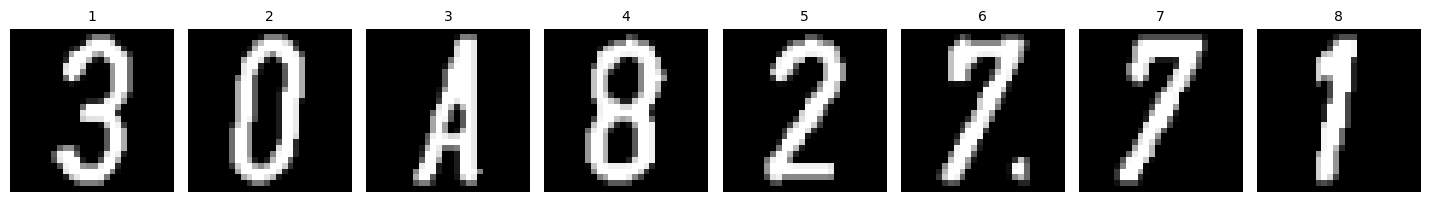

🎯 Đúng kỳ vọng: 8 ký tự.


In [25]:
import numpy as np, cv2, matplotlib.pyplot as plt


def _split_rows_kmeans_like(boxes):
    # Cluster y-centers into two rows without external deps (mini k-means on 1D)
    ys = np.array([y + h / 2.0 for (_, y, _, h) in boxes], dtype=np.float32).reshape(-1, 1)
    # init centroids at extremes
    c1, c2 = float(np.min(ys)), float(np.max(ys))
    for _ in range(15):
        d1 = np.abs(ys - c1)
        d2 = np.abs(ys - c2)
        m1 = (d1 <= d2).ravel()
        if m1.sum() == 0 or m1.sum() == len(ys):
            break
        nc1 = float(ys[m1].mean())
        nc2 = float(ys[~m1].mean())
        if abs(nc1 - c1) + abs(nc2 - c2) < 1e-3:
            c1, c2 = nc1, nc2
            break
        c1, c2 = nc1, nc2
    # assign and ensure top is the smaller y cluster
    m1 = (np.abs(ys - c1) <= np.abs(ys - c2)).ravel()
    top_mask = m1 if c1 <= c2 else ~m1
    top_boxes = [b for i, b in enumerate(boxes) if top_mask[i]]
    bot_boxes = [b for i, b in enumerate(boxes) if not top_mask[i]]
    return top_boxes, bot_boxes


def normalize_and_sort_characters(binary_inverted: np.ndarray, boxes, size: int = 28, pad: int = 2):
    # Sắp xếp theo quy tắc: hàng trên trước, rồi hàng dưới; trong mỗi hàng: trái → phải
    if not boxes:
        return [], [], []

    # Row split: try 2-cluster on y-centers; fallback to 3 smallest y as top
    top_boxes, bot_boxes = _split_rows_kmeans_like(boxes)
    if len(top_boxes) != 3 and len(boxes) >= 3:
        # robust fallback for VN 2-row plates (3 top + 5 bottom)
        sorted_by_y = sorted(boxes, key=lambda b: b[1] + b[3] / 2.0)
        top_boxes = sorted_by_y[:3]
        bot_boxes = [b for b in boxes if b not in top_boxes]

    # sort each row by x (left → right)
    top_sorted = sorted(top_boxes, key=lambda b: b[0])
    bot_sorted = sorted(bot_boxes, key=lambda b: b[0])

    # Top row first, then bottom row
    boxes_sorted = top_sorted + bot_sorted

    chars_28 = []
    stats = []
    for idx, (x, y, w, h) in enumerate(boxes_sorted):
        char = binary_inverted[y:y + h, x:x + w]  # ký tự là trắng trên nền đen
        # Make square canvas and center glyph with padding
        side = max(w, h) + 2 * pad
        canvas = np.zeros((side, side), dtype=np.uint8)
        sx = (side - w) // 2
        sy = (side - h) // 2
        canvas[sy:sy + h, sx:sx + w] = char
        resized = cv2.resize(canvas, (size, size), interpolation=cv2.INTER_AREA)
        chars_28.append(resized)
        stats.append({
            'idx': idx,
            'x': x,
            'w': w,
            'h': h,
            'area': w * h,
            'aspect': w / (h + 1e-6),
            'fg_before': int(np.sum(char > 0)),
            'fg_after': int(np.sum(resized > 0))
        })

    return boxes_sorted, chars_28, stats


# Thực thi và trực quan hóa
sorted_boxes, char_images, char_stats = normalize_and_sort_characters(binary_inverted, char_boxes, size=28, pad=2)

num_chars = len(char_images)
print(f"✅ Số ký tự sau khi sắp xếp & chuẩn hóa: {num_chars}")

# Hiển thị các ký tự 28×28 theo thứ tự đọc (hàng trên → dưới, trái → phải)
cols = max(8, num_chars)
plt.figure(figsize=(1.8 * cols, 2.2))
for i, im in enumerate(char_images):
    ax = plt.subplot(1, cols, i + 1)
    ax.imshow(im, cmap='gray')
    ax.set_title(f"{i + 1}", fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

# Kiểm thử đơn giản: mong đợi 8 ký tự cho biển "30F78286"
if num_chars != 8:
    print(f"⚠️ Cảnh báo: Phát hiện {num_chars} ký tự (kỳ vọng 8). Bạn có thể điều chỉnh ngưỡng lọc ở cell trước.")
else:
    print("🎯 Đúng kỳ vọng: 8 ký tự.")

### So sánh biểu đồ đặc trưng trước/after chuẩn hóa
Minh họa phân bố kích thước và số pixel foreground cho từng ký tự trước và sau khi chuẩn hóa 28×28.

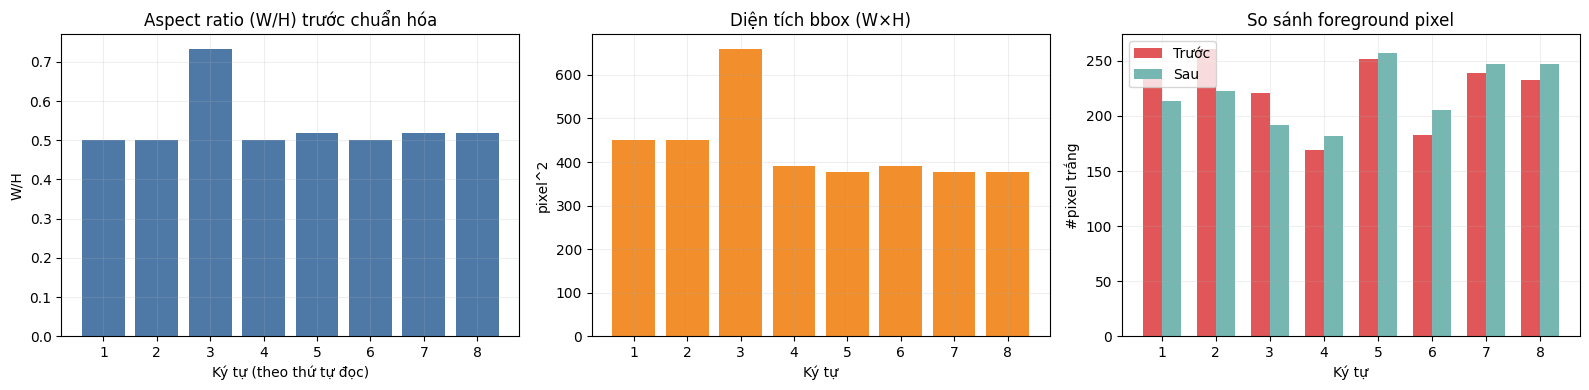

In [ ]:
import matplotlib.pyplot as plt, numpy as np
assert 'char_stats' in globals() and len(char_stats) > 0, "Chưa có thống kê ký tự để vẽ biểu đồ."

idxs = [s['idx']+1 for s in char_stats]
aspects = [s['aspect'] for s in char_stats]
areas = [s['area'] for s in char_stats]
fg_before = [s['fg_before'] for s in char_stats]
fg_after = [s['fg_after'] for s in char_stats]

fig, axes = plt.subplots(1, 3, figsize=(16,4))
# 1) Tỉ lệ Rộng/Cao (aspect)
axes[0].bar(idxs, aspects, color='#4e79a7')
axes[0].set_title('Aspect ratio (W/H) trước chuẩn hóa')
axes[0].set_xlabel('Ký tự (theo thứ tự đọc)'); axes[0].set_ylabel('W/H')
axes[0].grid(True, alpha=0.2)
# 2) Diện tích bbox
axes[1].bar(idxs, areas, color='#f28e2b')
axes[1].set_title('Diện tích bbox (W×H)')
axes[1].set_xlabel('Ký tự'); axes[1].set_ylabel('pixel^2')
axes[1].grid(True, alpha=0.2)
# 3) Foreground pixel: trước vs sau
width = 0.35
axes[2].bar(np.array(idxs)-width/2, fg_before, width=width, label='Trước', color='#e15759')
axes[2].bar(np.array(idxs)+width/2, fg_after,  width=width, label='Sau',   color='#76b7b2')
axes[2].set_title('So sánh foreground pixel')
axes[2].set_xlabel('Ký tự'); axes[2].set_ylabel('#pixel trắng')
axes[2].legend(); axes[2].grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# Bước 5: Nhận dạng ký tự với Tesseract (dùng module src/ocr_engine.py)


In [ ]:
from pathlib import Path
import sys
import numpy as np

# Thêm project root vào PYTHONPATH để import src/*
repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
# Fallback tuyệt đối nếu CWD khác
abs_root = Path('f:/code/XLA')
if abs_root.exists() and str(abs_root) not in sys.path:
    sys.path.insert(0, str(abs_root))

import importlib
# import src.ocr_engine as ocrm
import src.ocr_engine as ocrm
importlib.reload(ocrm)

ocr_characters = ocrm.ocr_characters
ocr_plate_line = ocrm.ocr_plate_line
combine_lines = ocrm.combine_lines
configure_tesseract = ocrm.configure_tesseract

configure_tesseract()

expected_plate = "30F82771"  # Ground truth để kiểm thử
plate_pred, plate_conf = None, None

try:
    if 'char_images' in globals() and isinstance(char_images, list) and len(char_images) > 0:
        # OCR từng ký tự rồi ghép chuỗi
        res = ocr_characters(char_images, vn_plate=True, lang='eng')
        plate_pred = res.text
        plate_conf = res.mean_conf
        print(f"Kết quả OCR từng ký tự: {plate_pred} (mean conf: {plate_conf}), kết quả chi tiết: {res}")
    elif 'plate_roi' in globals() and isinstance(plate_roi, np.ndarray):
        # Không có ảnh ký tự riêng lẻ -> OCR cả dòng biển số (dùng psm=11)
        res = ocr_plate_line(plate_roi, vn_plate=True, lang='eng', psm=11)
        plate_pred = res.text
        plate_conf = res.mean_conf
    else:
        raise RuntimeError('Không tìm thấy dữ liệu đầu vào cho OCR: cần char_images hoặc plate_roi')
except Exception as e:
    print('Lỗi OCR:', e)
    raise
else:
    print('Biển số dự đoán:', plate_pred)
    print('Độ tin cậy trung bình (mean conf):', plate_conf)
    if expected_plate:
        ok = (plate_pred == expected_plate)
        print('Khớp ground truth:', ok)

Kết quả OCR từng ký tự: 30A8277 (mean conf: 71.0), kết quả chi tiết: OCRResult(text='30A8277', confidences=[96.0, 96.0, -1.0, -1.0, 67.0, 0.0, 96.0, -1.0])
Biển số dự đoán: 30A8277
Độ tin cậy trung bình (mean conf): 71.0
Khớp ground truth: False


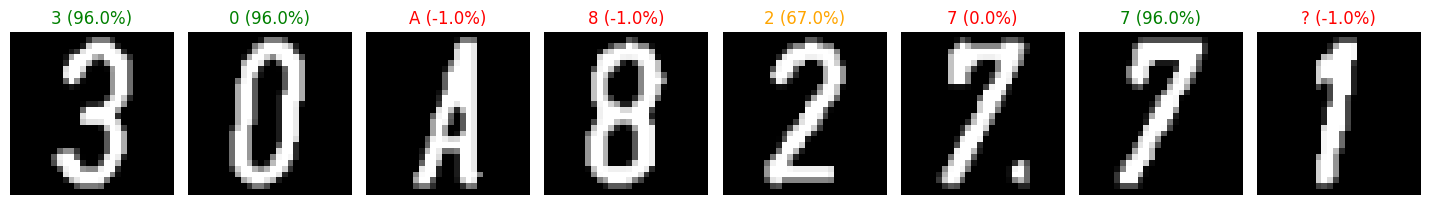

Per-char OCR result:
#1: '3' — 96.0%
#2: '0' — 96.0%
#3: 'A' — -1.0%
#4: '8' — -1.0%
#5: '2' — 67.0%
#6: '7' — 0.0%
#7: '7' — 96.0%


In [33]:
# Visualize per-char OCR predictions + confidences 
import math
import matplotlib.pyplot as plt
import numpy as np
import importlib
import src.ocr_engine as ocrm
importlib.reload(ocrm)

ocrm.configure_tesseract()

# Must have char_images defined from segmentation step
if 'char_images' not in globals() or len(char_images) == 0:
    raise RuntimeError("char_images missing — run segmentation cell first.")

# 1) Prefer batch ocr_characters result (it usually returns confidences list)
res = ocrm.ocr_characters(char_images, vn_plate=True, lang='eng')
text_batch = getattr(res, 'text', '') or ''
confs_batch = getattr(res, 'confidences', None) or getattr(res, 'confs', None) or []

# 2) If missing or mismatch, fallback to per-char OCR using ocr_single_char:
if not confs_batch or len(confs_batch) != len(char_images):
    confs_single = []
    chars_single = []
    for im in char_images:
        ch, conf = ocrm.ocr_single_char(im, whitelist=ocrm.letter_digit_whitelist(True), lang='eng')
        chars_single.append(ch or '?')
        confs_single.append(conf or 0.0)
    if not text_batch:
        text_batch = ''.join(chars_single)
    if not confs_batch:
        confs_batch = confs_single

# 3) Plot grid of char images with predicted value + confidence (colored: green/orange/red)
n = len(char_images)
cols = min(8, n)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.2))
axes = axes.flatten()

for i, ax in enumerate(axes[:n]):
    im = char_images[i]
    ax.imshow(im, cmap='gray')
    pred = text_batch[i] if i < len(text_batch) else '?'
    conf = float(confs_batch[i]) if i < len(confs_batch) else 0.0
    color = 'green' if conf >= 85 else 'orange' if conf >= 60 else 'red'
    ax.set_title(f"{pred} ({conf:.1f}%)", color=color, fontsize=12)
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(2)
    ax.axis('off')

# hide the rest of axes if any
for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# 4) Print per-char text/conf list for quick copy/paste
print("Per-char OCR result:")
for i, (ch, conf) in enumerate(zip(text_batch, confs_batch)):
    print(f"#{i+1}: '{ch}' — {conf:.1f}%")

## 🚀 Phase 1: Multi-Preset Detection
---
Test hệ thống detect mới sử dụng nhiều preset (car_square, car_rect, bike) và NMS để merge kết quả.

**Cải tiến:**
- `car_square`: Biển vuông 2 dòng xe hơi (AR: 0.7-2.0)
- `car_rect`: Biển chữ nhật 1 dòng xe hơi (AR: 2.8-6.5)
- `bike`: Biển xe máy 2 dòng (AR: 1.2-3.0)
- NMS (Non-Maximum Suppression) để loại bỏ detection trùng lặp

In [ ]:
# ============================================================================
# MULTI-PRESET DETECTION TEST
# ============================================================================
import sys
import os
import importlib

# Add src to path and reload modules
sys.path.insert(0, r'F:\CODE\XLA')
import src.lp_detector as lp_detector
importlib.reload(lp_detector)

from src.lp_detector import (
    detect_multi_preset, 
    detect_license_plates,
    classify_detected_plates,
    PRESETS,
    DEFAULT_MULTI_PRESETS
)
from src.preprocess import load_and_preprocess

print("✅ Loaded updated lp_detector module")
print(f"📋 Available presets: {list(PRESETS.keys())}")
print(f"📋 Default multi-presets: {DEFAULT_MULTI_PRESETS}")

✅ Loaded updated lp_detector module
📋 Available presets: ['car_square', 'car_rect', 'bike', 'car2', 'car1']
📋 Default multi-presets: ['car_square', 'car_rect', 'bike']


📁 Testing with 12 images


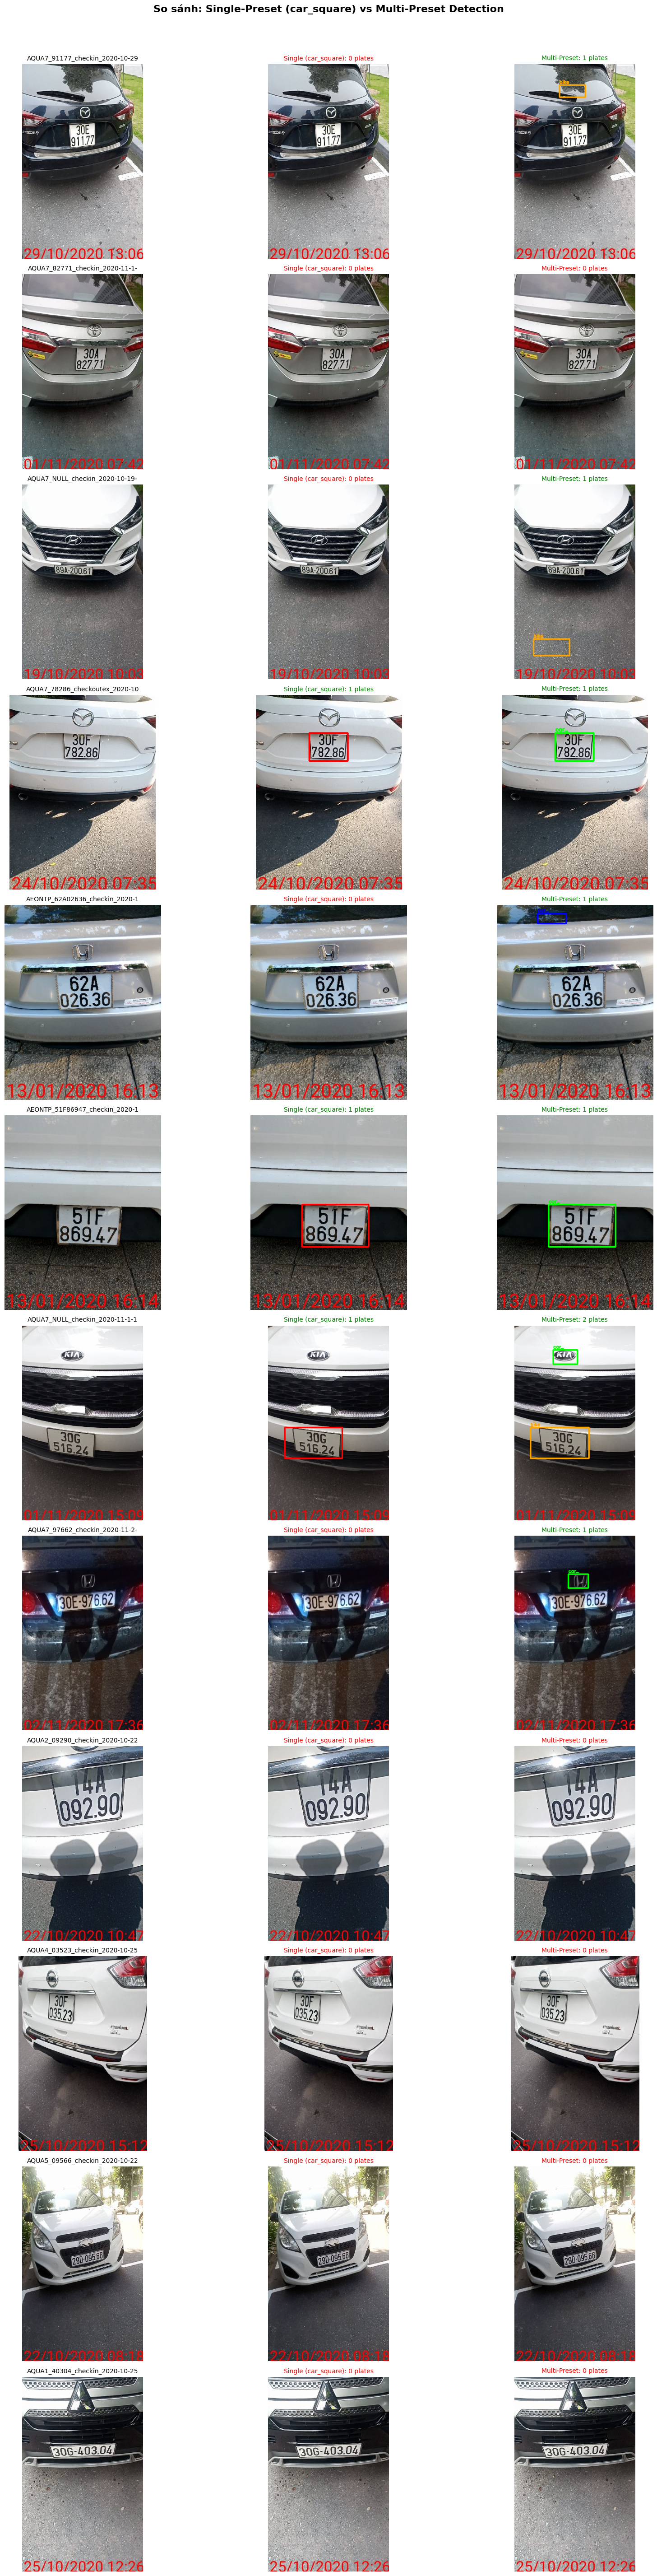


📊 DETECTION RESULTS SUMMARY
                         image  single_preset  multi_preset  car_square  car_rect  bike
AQUA7_91177_checkin_2020-10-29              0             1           0         0     1
AQUA7_82771_checkin_2020-11-1-              0             0           0         0     0
AQUA7_NULL_checkin_2020-10-19-              0             1           0         0     1
AQUA7_78286_checkoutex_2020-10              1             1           1         0     0
AEONTP_62A02636_checkin_2020-1              0             1           0         1     0
AEONTP_51F86947_checkin_2020-1              1             1           1         0     0
AQUA7_NULL_checkin_2020-11-1-1              1             2           1         0     1
AQUA7_97662_checkin_2020-11-2-              0             1           1         0     0
AQUA2_09290_checkin_2020-10-22              0             0           0         0     0
AQUA4_03523_checkin_2020-10-25              0             0           0         0     0
AQU

In [ ]:
# ============================================================================
# TEST: SO SÁNH SINGLE-PRESET VS MULTI-PRESET DETECTION
# ============================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

# Lấy danh sách test images (mix các loại biển)
test_folder = r'F:\CODE\XLA\data\test_images\CarTGMT'
all_images = glob(os.path.join(test_folder, '*.jpg'))

# Chọn 12 ảnh đa dạng để test
test_images = [
    # Biển vuông - góc thẳng
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_91177_checkin_2020-10-29-13-6OyGuWtJecr.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_82771_checkin_2020-11-1-7-42qzNT0orBVD.jpg',
    # Biển vuông - góc nghiêng  
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-10-19-10-3VNDtBDGikR.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_78286_checkoutex_2020-10-24-7-35_t4_Sdhb7B.jpg',
    # Có thể là biển chữ nhật
    r'F:\CODE\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AEONTP_51F86947_checkin_2020-1-13-16-15sUVxP1Ihlt.jpg',
    # Ảnh khó
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_NULL_checkin_2020-11-1-15-93yek_xsMxg.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA7_97662_checkin_2020-11-2-17-37AU9BTVtt4r.jpg',
    # Thêm một số ảnh random
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA2_09290_checkin_2020-10-22-10-47kCHb4hd9Qd.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA4_03523_checkin_2020-10-25-15-12ulXbmqjH2w.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA5_09566_checkin_2020-10-22-8-18mr16q4sxtm.jpg',
    r'F:\CODE\XLA\data\test_images\CarTGMT\AQUA1_40304_checkin_2020-10-25-12-277bdC7U4qUk.jpg',
]

# Filter valid images
test_images = [p for p in test_images if os.path.exists(p)]
print(f"📁 Testing with {len(test_images)} images")

# Run comparison
num_images = len(test_images)
fig, axes = plt.subplots(num_images, 3, figsize=(18, 5 * num_images))
fig.suptitle('So sánh: Single-Preset (car_square) vs Multi-Preset Detection', fontsize=16, fontweight='bold')

results_summary = []

for i, img_path in enumerate(test_images):
    # Load and preprocess
    processed = load_and_preprocess(img_path)
    if not processed:
        print(f"❌ Failed to load: {img_path}")
        continue
    
    clahe_img = processed['clahe']
    original_img = processed['original']
    img_name = os.path.basename(img_path)[:30]
    
    # Method 1: Single preset (old method)
    plates_single, _ = detect_license_plates(clahe_img, mode="car_square", debug=False)
    
    # Method 2: Multi-preset (new method)
    plates_multi, debug_info = detect_multi_preset(clahe_img, debug=True)
    
    # Classify detected plates
    classified = classify_detected_plates(plates_multi)
    
    results_summary.append({
        'image': img_name,
        'single_preset': len(plates_single),
        'multi_preset': len(plates_multi),
        'car_square': len(classified['car_square']),
        'car_rect': len(classified['car_rect']),
        'bike': len(classified['bike']),
    })
    
    # Visualize
    # Column 1: Original
    ax1 = axes[i, 0]
    ax1.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    ax1.set_title(f'{img_name}', fontsize=10)
    ax1.axis('off')
    
    # Column 2: Single preset result
    result_single = cv2.cvtColor(original_img.copy(), cv2.COLOR_BGR2RGB)
    for (x, y, w, h) in plates_single:
        cv2.rectangle(result_single, (x, y), (x+w, y+h), (255, 0, 0), 3)
    ax2 = axes[i, 1]
    ax2.imshow(result_single)
    ax2.set_title(f'Single (car_square): {len(plates_single)} plates', fontsize=10, 
                  color='green' if len(plates_single) > 0 else 'red')
    ax2.axis('off')
    
    # Column 3: Multi-preset result
    result_multi = cv2.cvtColor(original_img.copy(), cv2.COLOR_BGR2RGB)
    colors = {'car_square': (0, 255, 0), 'car_rect': (0, 0, 255), 'bike': (255, 165, 0)}
    for plate_type, plate_list in classified.items():
        for (x, y, w, h) in plate_list:
            color = colors.get(plate_type, (0, 255, 0))
            cv2.rectangle(result_multi, (x, y), (x+w, y+h), color, 3)
            cv2.putText(result_multi, plate_type[:4], (x, y-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    ax3 = axes[i, 2]
    ax3.imshow(result_multi)
    ax3.set_title(f'Multi-Preset: {len(plates_multi)} plates', fontsize=10,
                  color='green' if len(plates_multi) > 0 else 'red')
    ax3.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# Print summary
print("\n" + "="*70)
print("📊 DETECTION RESULTS SUMMARY")
print("="*70)
import pandas as pd
df = pd.DataFrame(results_summary)
print(df.to_string(index=False))
print("\n✅ Single-preset success rate:", f"{(df['single_preset'] > 0).mean()*100:.1f}%")
print("✅ Multi-preset success rate:", f"{(df['multi_preset'] > 0).mean()*100:.1f}%")

🔍 Debug image: AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg
📐 Image size: (623, 500)

📌 CAR_SQUARE
   AR range: (0.7, 2.0)
   Kernel: (25, 7)
   Contours: 23 → Plates: 0
   Rejected: {'area': 22, 'aspect': 1, 'solidity': 0, 'margin': 0}

📌 CAR_RECT
   AR range: (2.8, 6.5)
   Kernel: (45, 5)
   Contours: 28 → Plates: 0
   Rejected: {'area': 25, 'aspect': 1, 'solidity': 0, 'margin': 2}

📌 BIKE
   AR range: (1.2, 3.0)
   Kernel: (20, 7)
   Contours: 37 → Plates: 1
   Rejected: {'area': 33, 'aspect': 2, 'solidity': 0, 'margin': 1}


C:\Users\Admin\AppData\Local\Temp\ipykernel_5532\2589058616.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
f:\CODE\XLA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
f:\CODE\XLA\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


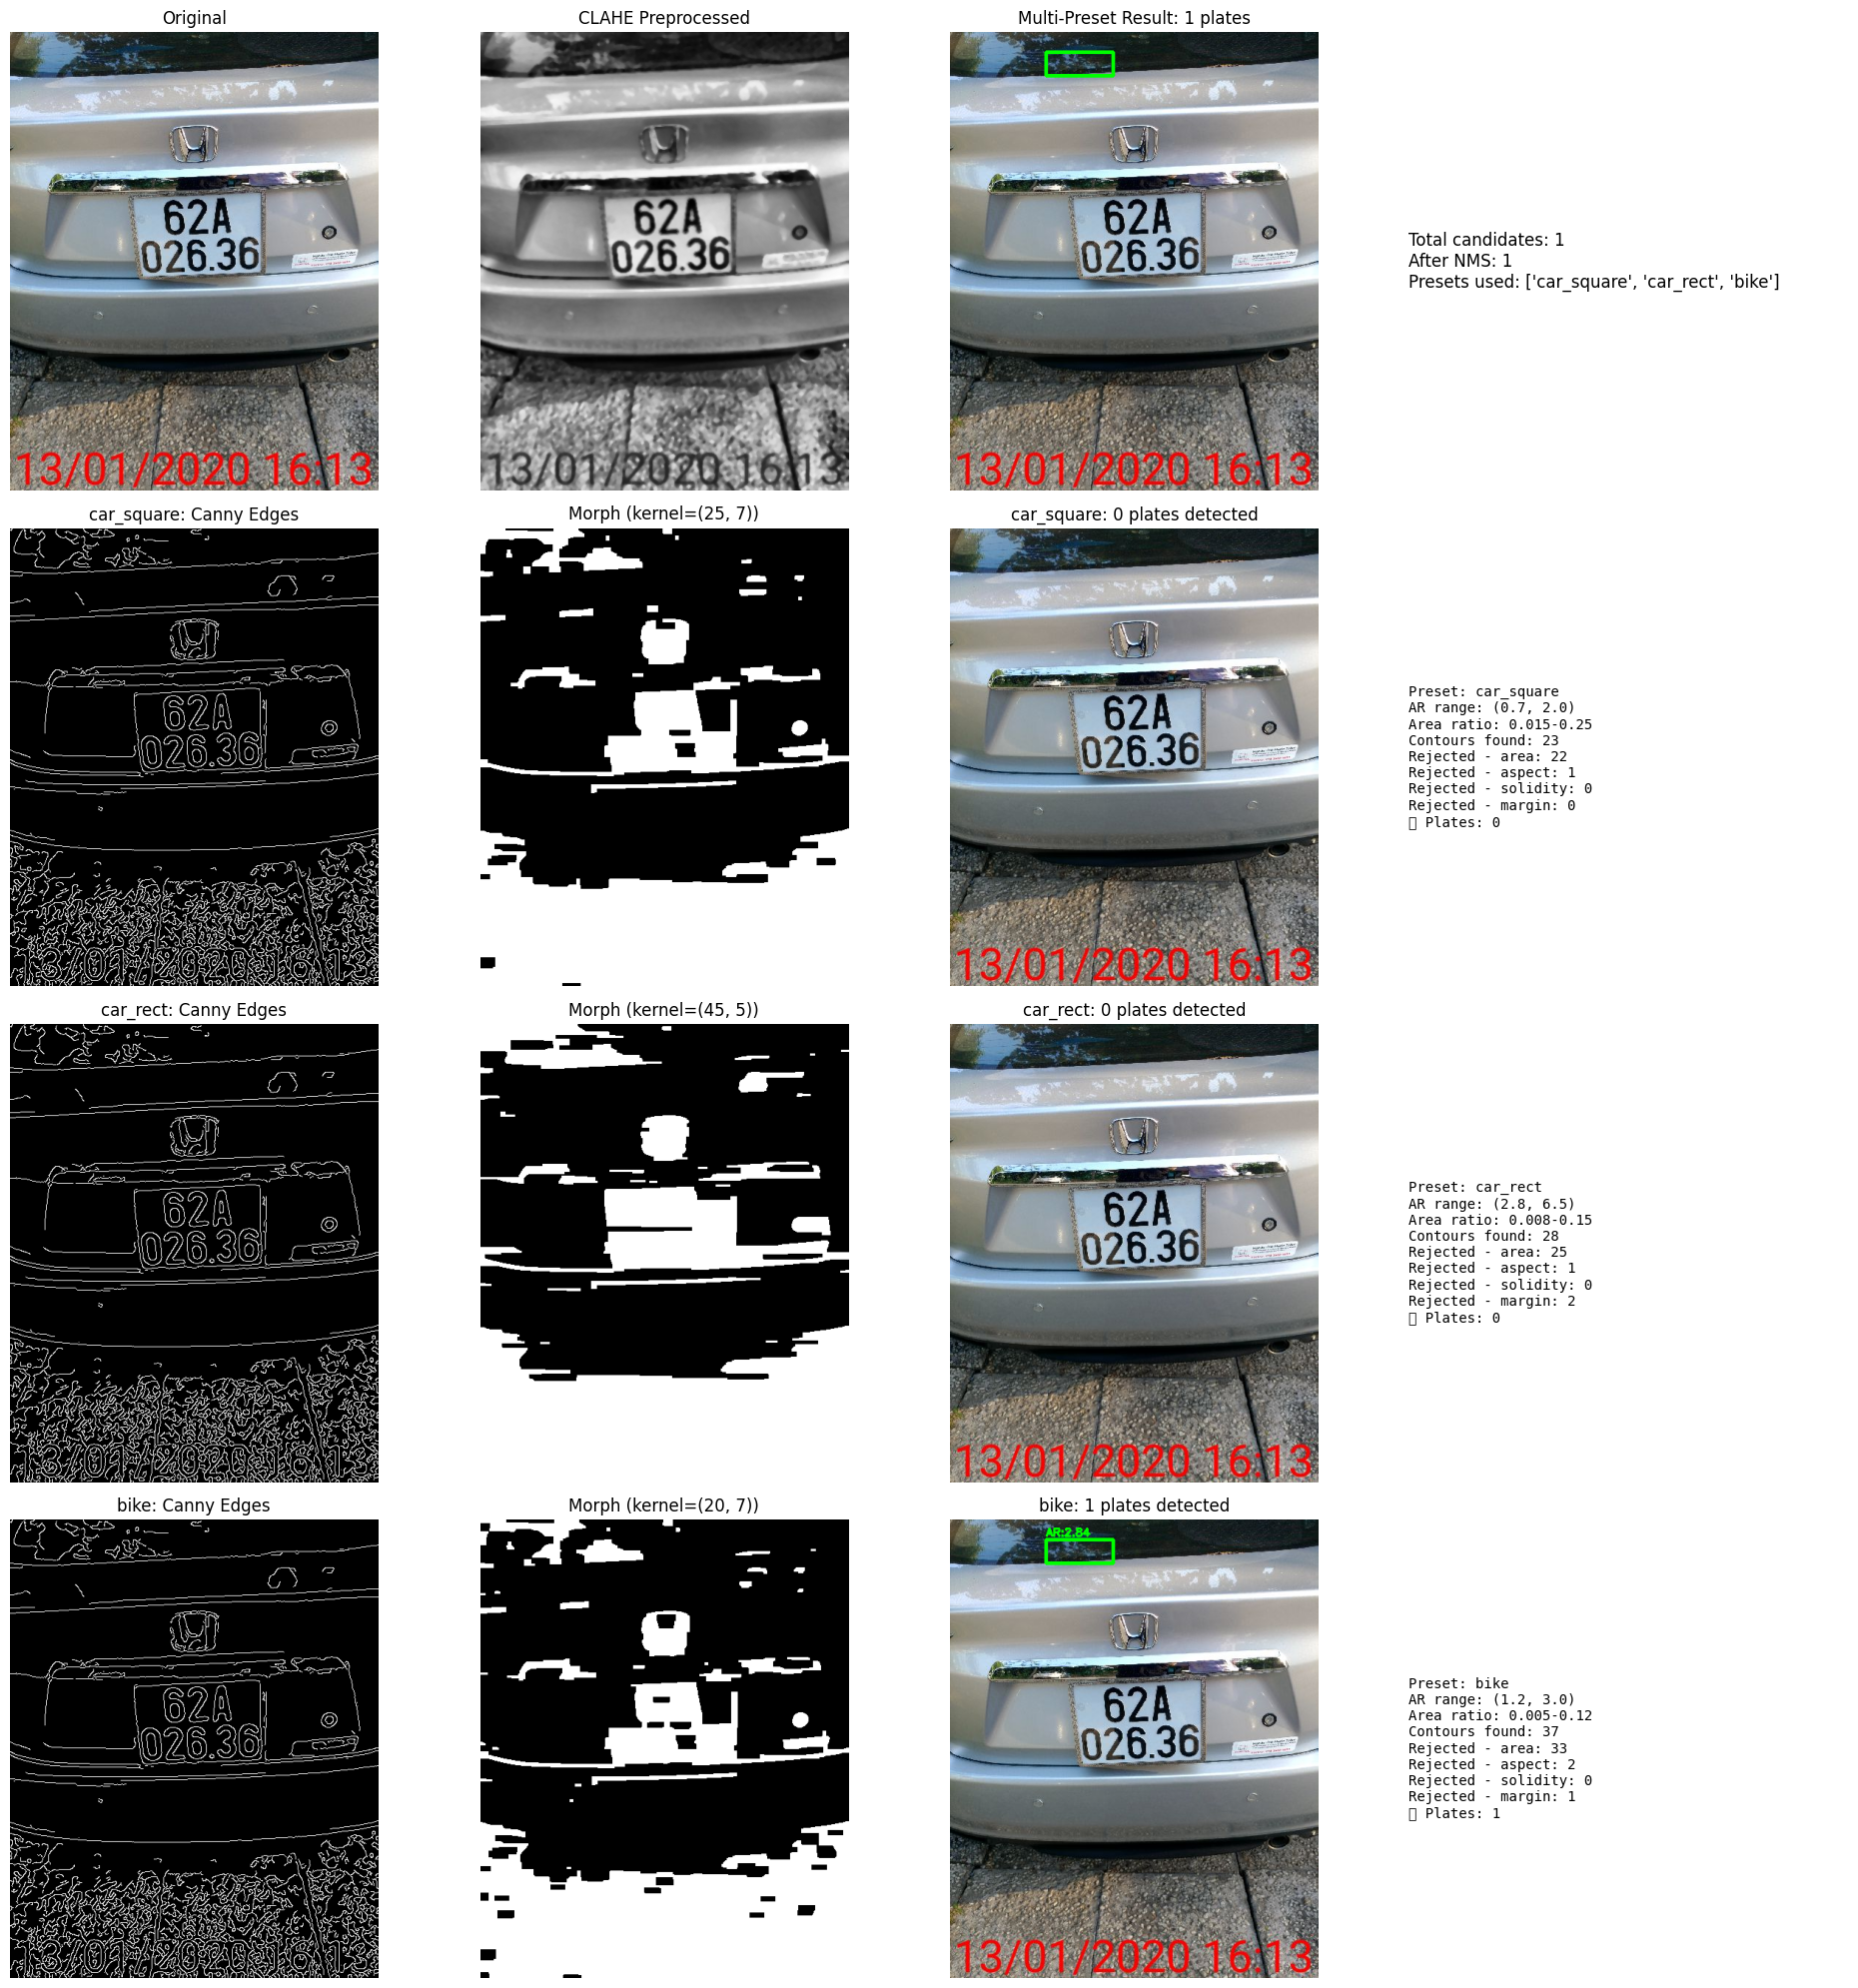

In [ ]:
# ============================================================================
# TEST: CHI TIẾT DEBUG CHO TỪNG PRESET
# ============================================================================

# Chọn 1 ảnh để debug chi tiết
debug_image_path = r'F:\CODE\XLA\data\test_images\CarTGMT\AEONTP_62A02636_checkin_2020-1-13-16-14gXI_gF3J5Z.jpg'

processed = load_and_preprocess(debug_image_path)
clahe_img = processed['clahe']
original_img = processed['original']

print(f"🔍 Debug image: {os.path.basename(debug_image_path)}")
print(f"📐 Image size: {clahe_img.shape}")

# Test each preset individually
preset_names = ["car_square", "car_rect", "bike"]
fig, axes = plt.subplots(len(preset_names) + 1, 4, figsize=(20, 5 * (len(preset_names) + 1)))

# Row 0: Original and preprocessed
axes[0, 0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(clahe_img, cmap='gray')
axes[0, 1].set_title('CLAHE Preprocessed')
axes[0, 1].axis('off')

# Final multi-preset result
plates_final, final_info = detect_multi_preset(clahe_img, debug=True)
result_final = cv2.cvtColor(original_img.copy(), cv2.COLOR_BGR2RGB)
for (x, y, w, h) in plates_final:
    cv2.rectangle(result_final, (x, y), (x+w, y+h), (0, 255, 0), 3)
axes[0, 2].imshow(result_final)
axes[0, 2].set_title(f'Multi-Preset Result: {len(plates_final)} plates')
axes[0, 2].axis('off')

axes[0, 3].axis('off')
axes[0, 3].text(0.1, 0.5, f"Total candidates: {final_info['total_candidates']}\n"
                          f"After NMS: {final_info['final_count']}\n"
                          f"Presets used: {final_info['presets_used']}",
                fontsize=12, transform=axes[0, 3].transAxes, verticalalignment='center')

# Rows 1-3: Individual preset results
for i, preset in enumerate(preset_names, 1):
    plates, info = detect_license_plates(clahe_img, mode=preset, debug=True)
    config = PRESETS[preset]
    
    # Edges
    axes[i, 0].imshow(info['edges'], cmap='gray')
    axes[i, 0].set_title(f'{preset}: Canny Edges')
    axes[i, 0].axis('off')
    
    # Morphology
    axes[i, 1].imshow(info['morph'], cmap='gray')
    axes[i, 1].set_title(f'Morph (kernel={info["kernel_close"]})')
    axes[i, 1].axis('off')
    
    # Detection result
    result_img = cv2.cvtColor(original_img.copy(), cv2.COLOR_BGR2RGB)
    for (x, y, w, h) in plates:
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        ar = w / h
        cv2.putText(result_img, f'AR:{ar:.2f}', (x, y-5), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    axes[i, 2].imshow(result_img)
    axes[i, 2].set_title(f'{preset}: {len(plates)} plates detected')
    axes[i, 2].axis('off')
    
    # Stats
    axes[i, 3].axis('off')
    stats_text = (f"Preset: {preset}\n"
                  f"AR range: {config.aspect_ratio_range}\n"
                  f"Area ratio: {config.min_area_ratio}-{config.max_area_ratio}\n"
                  f"Contours found: {info['contours']}\n"
                  f"Rejected - area: {info['rejected']['area']}\n"
                  f"Rejected - aspect: {info['rejected']['aspect']}\n"
                  f"Rejected - solidity: {info['rejected']['solidity']}\n"
                  f"Rejected - margin: {info['rejected']['margin']}\n"
                  f"✅ Plates: {len(plates)}")
    axes[i, 3].text(0.1, 0.5, stats_text, fontsize=10, 
                    transform=axes[i, 3].transAxes, verticalalignment='center',
                    family='monospace')
    
    print(f"\n{'='*50}")
    print(f"📌 {preset.upper()}")
    print(f"   AR range: {config.aspect_ratio_range}")
    print(f"   Kernel: {info['kernel_close']}")
    print(f"   Contours: {info['contours']} → Plates: {len(plates)}")
    print(f"   Rejected: {info['rejected']}")

plt.tight_layout()
plt.show()

## 🔄 Phase 2: Perspective Correction
---
Xử lý biển số bị nghiêng/xéo bằng cách:
1. **Find 4-corner contour**: Tìm 4 góc của biển số thực tế (không phải bounding box)
2. **Perspective Transform**: Warp về hình chữ nhật chuẩn
3. **Deskew**: Xoay để text nằm ngang

**Các hàm mới:**
- `find_plate_contour()`: Tìm 4 góc biển số
- `perspective_transform()`: Warp perspective
- `compute_skew_angle()`: Tính góc nghiêng bằng Hough lines
- `deskew_image()`: Xoay ảnh để text nằm ngang
- `correct_plate_perspective_and_skew()`: Pipeline hoàn chỉnh